# seg_lambda=0.3, alpha=0.5000

## 1. Paths & Training Hyperparameters

In [2]:
import os, sys, math, time, random, itertools
from typing import Tuple, List, Dict
import timm

IMG_ROOT = r"C:\Users\Steven\Desktop\Final Project\Datasets\Dataset_1\Chest X-Ray Images with Pneumothorax Masks\png_images"
TRAIN_CSV = r"C:\Users\Steven\Desktop\Final Project\Datasets\Dataset_1\Chest X-Ray Images with Pneumothorax Masks\stage_1_train_images.csv"
TEST_CSV  = r"C:\Users\Steven\Desktop\Final Project\Datasets\Dataset_1\Chest X-Ray Images with Pneumothorax Masks\stage_1_test_images.csv"
MASK_ROOT = IMG_ROOT.replace("png_images", "png_masks")  

OUT_DIR   = "./Baseline+ECA(SamplerGNUNet++)_Output"

IMG_SIZE  = 576  
EPOCHS    = 120       
BATCH     = 4         
LR        = 2e-4
SEED      = 42
VAL_RATIO = 0.20       
SAMPLER   = "on"  

print("IMG_ROOT:", IMG_ROOT)
print("TRAIN_CSV:", TRAIN_CSV)
print("TEST_CSV:", TEST_CSV)
print("OUT_DIR:", OUT_DIR)
print("EPOCHS/BATCH/LR:", EPOCHS, BATCH, LR)
print("VAL_RATIO/SAMPLER:", VAL_RATIO, SAMPLER)

IMG_ROOT: C:\Users\Steven\Desktop\Final Project\Datasets\Dataset_1\Chest X-Ray Images with Pneumothorax Masks\png_images
TRAIN_CSV: C:\Users\Steven\Desktop\Final Project\Datasets\Dataset_1\Chest X-Ray Images with Pneumothorax Masks\stage_1_train_images.csv
TEST_CSV: C:\Users\Steven\Desktop\Final Project\Datasets\Dataset_1\Chest X-Ray Images with Pneumothorax Masks\stage_1_test_images.csv
OUT_DIR: ./Baseline+ECA(SamplerGNUNet++)_Output
EPOCHS/BATCH/LR: 120 4 0.0002
VAL_RATIO/SAMPLER: 0.2 on


## 2. Imports & Device

In [3]:
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode
import torchvision

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score,
                             confusion_matrix, roc_curve, precision_recall_curve)

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams.update({"figure.dpi": 110})

def set_seed(seed: int = 42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(SEED)
print(f"Using device: {device} | AMP: {'on' if device.type=='cuda' else 'off'}")

Using device: cuda | AMP: on


## 3. Read CSVs & Quick Preview

In [4]:
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

display(train_df.head(8))
display(test_df.head(8))

print("Train shape:", train_df.shape, "Columns:", list(train_df.columns))
print("Test  shape:", test_df.shape, "Columns:", list(test_df.columns))

print("Train label distribution:", train_df["has_pneumo"].value_counts().to_dict())
print("Test  label distribution:", test_df["has_pneumo"].value_counts().to_dict())

,new_filename,ImageId,has_pneumo
0,0_train_0_.png,1.2.276.0.7230010.3.1.4.8323329.5597.151787518...,0
1,1_train_0_.png,1.2.276.0.7230010.3.1.4.8323329.12515.15178752...,0
2,2_train_1_.png,1.2.276.0.7230010.3.1.4.8323329.4904.151787518...,1
3,3_train_1_.png,1.2.276.0.7230010.3.1.4.8323329.32579.15178751...,1
4,4_train_1_.png,1.2.276.0.7230010.3.1.4.8323329.1314.151787516...,1
5,5_train_0_.png,1.2.276.0.7230010.3.1.4.8323329.11364.15178752...,0
6,6_train_0_.png,1.2.276.0.7230010.3.1.4.8323329.4541.151787518...,0
7,7_train_1_.png,1.2.276.0.7230010.3.1.4.8323329.4440.151787518...,1


,new_filename,ImageId,has_pneumo
0,0_test_1_.png,1.2.276.0.7230010.3.1.4.8323329.5797.151787519...,1
1,1_test_0_.png,1.2.276.0.7230010.3.1.4.8323329.5798.151787519...,0
2,2_test_0_.png,1.2.276.0.7230010.3.1.4.8323329.5799.151787519...,0
3,3_test_0_.png,1.2.276.0.7230010.3.1.4.8323329.580.1517875163...,0
4,4_test_0_.png,1.2.276.0.7230010.3.1.4.8323329.5800.151787519...,0
5,5_test_0_.png,1.2.276.0.7230010.3.1.4.8323329.5801.151787519...,0
6,6_test_1_.png,1.2.276.0.7230010.3.1.4.8323329.5802.151787519...,1
7,7_test_1_.png,1.2.276.0.7230010.3.1.4.8323329.5803.151787519...,1


Train shape: (10675, 3) Columns: ['new_filename', 'ImageId', 'has_pneumo']
Test  shape: (1372, 3) Columns: ['new_filename', 'ImageId', 'has_pneumo']
Train label distribution: {0: 8296, 1: 2379}
Test  label distribution: {0: 1082, 1: 290}


## 4. Full-path Resolution & Dataset 

In [5]:
def resolve_full_paths(df: pd.DataFrame, img_root: str) -> pd.DataFrame:
    df = df.copy()
    def _resolve(row):
        name = str(row["new_filename"])
        name_png = name if name.lower().endswith(".png") else f"{name}.png"
        p1 = os.path.join(img_root, name_png)
        if os.path.exists(p1):
            return p1
        # fallback: ImageId.png
        alt = os.path.join(img_root, f"{row['ImageId']}.png")
        return alt if os.path.exists(alt) else p1
    df["full_path"] = df.apply(_resolve, axis=1)
    return df

train_df = resolve_full_paths(train_df, IMG_ROOT)
test_df  = resolve_full_paths(test_df,  IMG_ROOT)

missing_train = (~train_df["full_path"].apply(os.path.exists)).sum()
missing_test  = (~test_df["full_path"].apply(os.path.exists)).sum()
print(f"Missing files — Train: {missing_train} | Test: {missing_test}")

class PandasImageDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["full_path"]).convert("L")
        if self.transform: img = self.transform(img)
        y = int(row["has_pneumo"])
        return img, y
    
class JointImageMaskTransform:
    def __init__(self, out_size=IMG_SIZE):
        self.out_size = out_size

    def __call__(self, img, mask):
        # Resize + RandomResizedCrop + RandomHorizontalFlip + ToTensor + Normalize
        resize_to = int(self.out_size * 1.1)
        img  = TF.resize(img,  (resize_to, resize_to), interpolation=InterpolationMode.BILINEAR)
        mask = TF.resize(mask, (resize_to, resize_to), interpolation=InterpolationMode.NEAREST)

        i, j, h, w = torchvision.transforms.RandomResizedCrop.get_params(
            img,
            scale=(0.8, 1.0),
            ratio=(0.9, 1.1)
        )
        img  = TF.resized_crop(img,  i, j, h, w, (self.out_size, self.out_size),
                               interpolation=InterpolationMode.BILINEAR)
        mask = TF.resized_crop(mask, i, j, h, w, (self.out_size, self.out_size),
                               interpolation=InterpolationMode.NEAREST)

        if random.random() < 0.5:
            img  = TF.hflip(img)
            mask = TF.hflip(mask)

        if random.random() < 0.5:
            angle = random.uniform(-7, 7)
            img  = TF.rotate(img, angle, interpolation=InterpolationMode.BILINEAR)
            mask = TF.rotate(mask, angle, interpolation=InterpolationMode.NEAREST)

        if random.random() < 0.5:
            b_factor = 1.0 + random.uniform(-0.15, 0.15)
            c_factor = 1.0 + random.uniform(-0.15, 0.15)
            img = TF.adjust_brightness(img, b_factor)
            img = TF.adjust_contrast(img, c_factor)

        img  = TF.to_tensor(img)               # [1,H,W], [0,1]
        img  = TF.normalize(img, [0.5], [0.25])

        mask = TF.to_tensor(mask)              # [1,H,W], [0,1]
        mask = (mask > 0.5).float()            # Binarize

        return img, mask

class PandasImageMaskDataset(Dataset):
    def __init__(self, df: pd.DataFrame, mask_root: str, joint_transform: JointImageMaskTransform):
        self.df = df.reset_index(drop=True)
        self.mask_root = mask_root
        self.joint_transform = joint_transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Images come from full_path
        img_path = row["full_path"]
        img = Image.open(img_path).convert("L")

        # Masks come from mask_root + basename
        basename = os.path.basename(img_path)
        mask_path = os.path.join(self.mask_root, basename)

        if not os.path.exists(mask_path):
            raise FileNotFoundError(f"Mask not found for {img_path} -> {mask_path}")

        mask = Image.open(mask_path).convert("L")

        img, mask = self.joint_transform(img, mask)

        y = float(row["has_pneumo"])
        return img, y, mask

Missing files — Train: 0 | Test: 0


In [6]:
os.makedirs(OUT_DIR, exist_ok=True)
EDA_DIR = os.path.join(OUT_DIR, "eda"); os.makedirs(EDA_DIR, exist_ok=True)

def eda_class_distribution(df: pd.DataFrame, label_col: str, out_path: str, title: str):
    counts = df[label_col].value_counts().sort_index()
    plt.figure(figsize=(6,4))
    xs = [str(int(x)) for x in counts.index.tolist()]
    ys = counts.values.astype(int)
    plt.bar(xs, ys)
    for i, y in enumerate(ys):
        plt.text(i, y, str(y), ha="center", va="bottom", fontsize=9)
    plt.title(f"Class Distribution — {title}")
    plt.xlabel("Label"); plt.ylabel("Count")
    plt.tight_layout(); plt.savefig(out_path); plt.show()

def eda_missing_files(df: pd.DataFrame, out_txt: str, title: str):
    missing_mask = ~df["full_path"].apply(os.path.exists)
    total = len(df); missing = missing_mask.sum()
    with open(out_txt, "w", encoding="utf-8") as f:
        f.write(f"Total rows: {total}\nMissing files: {missing}\n")
        if missing:
            f.write("First 50 missing examples:\n")
            f.write("\n".join(df.loc[missing_mask, "full_path"].head(50).tolist()))
    print(f"[{title}] Missing: {missing}/{total} — saved to {out_txt}")

def eda_sample_grid(df: pd.DataFrame, out_path: str, title: str, n_per_class: int = 8, size: int = 128):
    labels = sorted(df["has_pneumo"].unique().tolist())
    panels = []
    for lab in labels:
        subset = df[df["has_pneumo"] == lab]
        sample = subset.sample(min(n_per_class, len(subset)), random_state=0)
        panels.append(sample)

    cols = n_per_class; rows = len(labels)
    plt.figure(figsize=(cols*2, rows*2))
    idx = 1
    for r, panel in enumerate(panels):
        for _, row in panel.iterrows():
            fp = row["full_path"]
            plt.subplot(rows, cols, idx)
            try:
                img = Image.open(fp).convert("L").resize((size,size))
                plt.imshow(img, cmap="gray"); plt.axis("off")
            except Exception:
                plt.text(0.5,0.5,"missing",ha="center",va="center"); plt.axis("off")
            idx += 1
    plt.suptitle(f"Sample Grid — {title}", y=0.98)
    plt.tight_layout(); plt.savefig(out_path); plt.show()

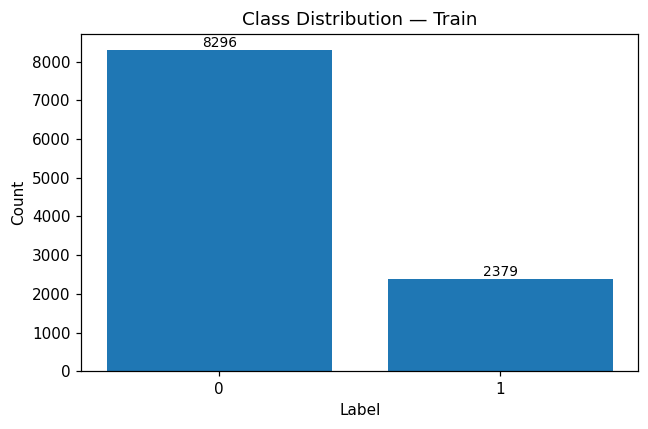

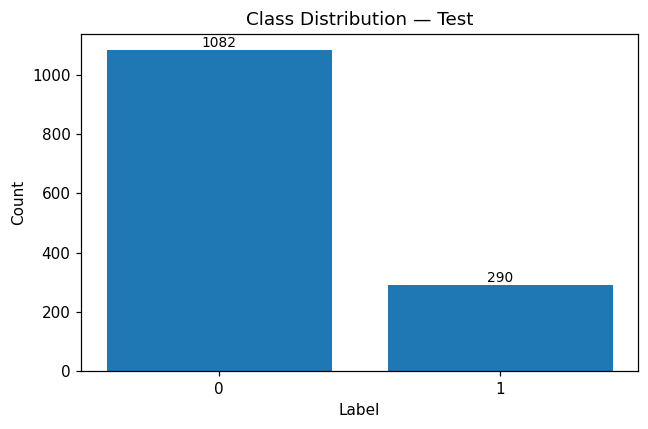

[Train] Missing: 0/10675 — saved to ./Baseline+ECA(SamplerGNUNet++)_Output\eda\missing_train.txt
[Test] Missing: 0/1372 — saved to ./Baseline+ECA(SamplerGNUNet++)_Output\eda\missing_test.txt


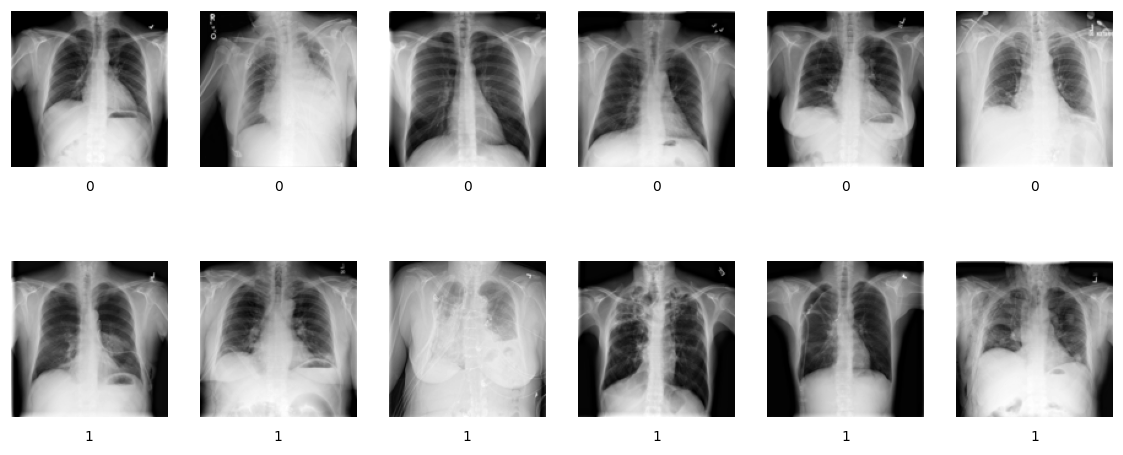

In [7]:
from pathlib import Path

eda_class_distribution(train_df, "has_pneumo", os.path.join(EDA_DIR, "class_dist_train.png"), "Train")
eda_class_distribution(test_df,  "has_pneumo", os.path.join(EDA_DIR, "class_dist_test.png"),  "Test")

eda_missing_files(train_df, os.path.join(EDA_DIR, "missing_train.txt"), "Train")
eda_missing_files(test_df,  os.path.join(EDA_DIR, "missing_test.txt"),  "Test")

def eda_sample_grid(df, out_path, split_name, n_per_class=6, size=128):
    label_col = "has_pneumo"
    path_col = "full_path" if "full_path" in df.columns else "filepath"

    classes = sorted(df[label_col].dropna().unique().tolist())
    nrows, ncols = len(classes), n_per_class
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*2.2, nrows*2.4))
    if nrows == 1:
        axes = np.array([axes])

    for r, c in enumerate(classes):
        sub = df[df[label_col] == c]
        sampled = sub.sample(n=min(n_per_class, len(sub)), random_state=42) if len(sub) > 0 else sub
        sampled = sampled.reset_index(drop=True)

        for i in range(ncols):
            ax = axes[r, i]
            ax.set_axis_off()

            if i < len(sampled):
                row = sampled.iloc[i]
                img_path = str(Path(row[path_col]))
                try:
                    im = Image.open(img_path).convert("L")
                    if size:
                        im = im.resize((size, size))
                    ax.imshow(im, cmap="gray")
                except Exception:
                    ax.imshow(np.zeros((size, size)), cmap="gray")

                ax.text(0.5, -0.08, str(row[label_col]),
                        transform=ax.transAxes, ha="center", va="top", fontsize=9)
            else:
                ax.imshow(np.zeros((size, size)), cmap="gray")

    plt.subplots_adjust(hspace=0.6, wspace=0.05)
    plt.show()
    Path(os.path.dirname(out_path)).mkdir(parents=True, exist_ok=True)
    # fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

eda_sample_grid(train_df, os.path.join(EDA_DIR, "sample_grid_train.png"), "Train", n_per_class=6, size=128)

In [8]:
# Combine train + test for splitting
full_df = pd.concat([train_df, test_df], ignore_index=True)

print("Original full size:", len(full_df))
print("Label distribution (full):", full_df["has_pneumo"].value_counts().to_dict())

from sklearn.model_selection import train_test_split

# 20% of the data for val + test
train_tmp, temp_df = train_test_split(
    full_df,
    test_size=0.2,               
    stratify=full_df["has_pneumo"],
    random_state=SEED,
)

# 10% val, 10% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,              
    stratify=temp_df["has_pneumo"],
    random_state=SEED,
)

tr_df = train_tmp.reset_index(drop=True)

print("8:1:1 split sizes ->",
      "Train:", len(tr_df),
      "Val:",   len(val_df),
      "Test:",  len(test_df))

print("Train label dist (before oversampling):",
      tr_df["has_pneumo"].value_counts().to_dict())
print("Val   label dist:",
      val_df["has_pneumo"].value_counts().to_dict())
print("Test  label dist:",
      test_df["has_pneumo"].value_counts().to_dict())

if SAMPLER == "off":
    # Oversampling minority class in training set
    pos_df = tr_df[tr_df["has_pneumo"] == 1]
    neg_df = tr_df[tr_df["has_pneumo"] == 0]

    n_pos = len(pos_df)
    n_neg = len(neg_df)
    target_pos = n_neg               

    factor    = target_pos // n_pos
    remainder = target_pos % n_pos

    pos_oversampled = pd.concat(
        [pos_df] * factor + [pos_df.sample(remainder, replace=True, random_state=SEED)],
        ignore_index=True
    )

    tr_df_bal = pd.concat([neg_df, pos_oversampled], ignore_index=True)
    tr_df_bal = tr_df_bal.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

    print("After oversampling Train label dist:",
          tr_df_bal["has_pneumo"].value_counts().to_dict())

    tr_df = tr_df_bal
else:
    print("SAMPLER is ON -> skip dataframe oversampling, use original imbalanced train set.")


Original full size: 12047
Label distribution (full): {0: 9378, 1: 2669}
8:1:1 split sizes -> Train: 9637 Val: 1205 Test: 1205
Train label dist (before oversampling): {0: 7502, 1: 2135}
Val   label dist: {0: 938, 1: 267}
Test  label dist: {0: 938, 1: 267}
SAMPLER is ON -> skip dataframe oversampling, use original imbalanced train set.


In [9]:
# Transforms
train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.25]),
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.25]),
])

# Joint transforms for image + mask (training set)
joint_train_tfms = JointImageMaskTransform(out_size=IMG_SIZE)

# Datasets
ds_train = PandasImageMaskDataset(tr_df, mask_root=MASK_ROOT, joint_transform=joint_train_tfms)
ds_val   = PandasImageDataset(val_df, transform=eval_tfms)
ds_test  = PandasImageDataset(test_df, transform=eval_tfms)

def make_weights_for_balancing(df: pd.DataFrame) -> np.ndarray:
    counts = df["has_pneumo"].value_counts().to_dict()
    return df["has_pneumo"].map(lambda y: 1.0 / counts[int(y)]).values.astype(np.float32)


if SAMPLER == "on":
    weights = make_weights_for_balancing(tr_df)
    sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)
    shuffle = False
else:
    sampler = None; shuffle = True

# DataLoaders
dl_train = DataLoader(ds_train, batch_size=BATCH, sampler=sampler, shuffle=shuffle,
                      num_workers=0, pin_memory=True)
dl_val   = DataLoader(ds_val, batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=True)
dl_test  = DataLoader(ds_test, batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=True)

# Use eval dataset for train_eval
ds_train_eval = PandasImageDataset(tr_df, transform=eval_tfms)
dl_train_eval = DataLoader(
    ds_train_eval, batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=True
)


len(ds_train), len(ds_val), len(ds_test)

(9637, 1205, 1205)

In [10]:
import os
import numpy as np
from PIL import Image

first_pos_idx = 1  

row = tr_df.iloc[first_pos_idx]
img_path = row["full_path"]
basename = os.path.basename(img_path)

print("img_path:", img_path)
print("basename:", basename)

print("MASK_ROOT:", MASK_ROOT)
mask_path = os.path.join(MASK_ROOT, basename)
print("mask_path:", mask_path, "exists:", os.path.exists(mask_path))

mask_raw = Image.open(mask_path).convert("L")
mask_np = np.array(mask_raw)

print("raw mask shape:", mask_np.shape)
print("raw mask min/max:", mask_np.min(), mask_np.max())
print("raw mask positive pixels (>0):", (mask_np > 0).sum())


img_path: C:\Users\Steven\Desktop\Final Project\Datasets\Dataset_1\Chest X-Ray Images with Pneumothorax Masks\png_images\1704_train_1_.png
basename: 1704_train_1_.png
MASK_ROOT: C:\Users\Steven\Desktop\Final Project\Datasets\Dataset_1\Chest X-Ray Images with Pneumothorax Masks\png_masks
mask_path: C:\Users\Steven\Desktop\Final Project\Datasets\Dataset_1\Chest X-Ray Images with Pneumothorax Masks\png_masks\1704_train_1_.png exists: True
raw mask shape: (1024, 1024)
raw mask min/max: 0 255
raw mask positive pixels (>0): 24341


In [11]:
pos_indices = [i for i, v in enumerate(tr_df["has_pneumo"].values) if v == 1]
print("Positive sample number:", len(pos_indices))
first_pos_idx = pos_indices[0]

img, y, mask = ds_train[first_pos_idx]
print("index:", first_pos_idx)
print("label:", y)
print("mask shape:", mask.shape)
print("mask min/max:", mask.min().item(), mask.max().item())
print("mask positive pixels:", mask.sum().item())

Positive sample number: 2135
index: 1
label: 1.0
mask shape: torch.Size([1, 576, 576])
mask min/max: 0.0 1.0
mask positive pixels: 8770.0


# ConvNeXt_V2
## DropPath (Random Depth)

In [12]:
def drop_path(x, drop_prob: float = 0.0, training: bool = False):
    if drop_prob == 0.0 or not training:
        return x
    keep_prob = 1.0 - drop_prob
    # Only sample along batch dimension, broadcast others
    shape = (x.shape[0],) + (1,) * (x.ndim - 1)
    random_tensor = keep_prob + torch.rand(shape, dtype=x.dtype, device=x.device)
    random_tensor.floor_()  # binarize
    return x * random_tensor / keep_prob

class DropPath(nn.Module):
    def __init__(self, drop_prob: float = 0.0):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        return drop_path(x, self.drop_prob, self.training)

## GRN

In [13]:
class GRN(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.gamma = nn.Parameter(torch.zeros(1, 1, 1, dim))
        self.beta = nn.Parameter(torch.zeros(1, 1, 1, dim))

    def forward(self, x):
        gx = torch.norm(x, p=2, dim=(1, 2), keepdim=True)                # [N,1,1,C]
        nx = gx / (gx.mean(dim=-1, keepdim=True) + 1e-6)                 # [N,1,1,C]
        return self.gamma * (x * nx) + self.beta + x                     # [N,H,W,C]

## LayerNorm2d

In [14]:
class LayerNorm2d(nn.Module):
    def __init__(self, num_channels: int, eps: float = 1e-6):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(num_channels))
        self.bias = nn.Parameter(torch.zeros(num_channels))
        self.eps = eps

    def forward(self, x):
        mean = x.mean(dim=1, keepdim=True)
        var = (x - mean).pow(2).mean(dim=1, keepdim=True)
        x = (x - mean) / torch.sqrt(var + self.eps)
        return self.weight.view(1, -1, 1, 1) * x + self.bias.view(1, -1, 1, 1)

## ECA

In [15]:
class ECALayer(nn.Module):
    def __init__(self, channels: int, k_size: int = 3):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(
            in_channels=1,
            out_channels=1,
            kernel_size=k_size,
            padding=(k_size - 1) // 2,
            bias=False,
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x: [B, C, H, W]
        y = self.avg_pool(x)                    # [B, C, 1, 1]
        y = y.squeeze(-1).transpose(-1, -2)     # [B, 1, C]
        y = self.conv(y)                        # [B, 1, C]
        y = self.sigmoid(y)
        y = y.transpose(-1, -2).unsqueeze(-1)   # [B, C, 1, 1]
        return x * y


## ConvNeXt_V2 block

In [16]:
class ConvNeXtV2Block(nn.Module):
    def __init__(
        self,
        dim: int,
        mlp_ratio: float = 4.0,
        drop_path: float = 0.0,
        layer_scale_init_value: float = 0.0,  
    ):
        super().__init__()
        # 7x7 depthwise convolution
        self.dwconv = nn.Conv2d(dim, dim, kernel_size=7, padding=3, groups=dim)

        # Do LayerNorm in channels_last format
        self.norm = nn.LayerNorm(dim, eps=1e-6)

        hidden_dim = int(dim * mlp_ratio)
        self.pwconv1 = nn.Linear(dim, hidden_dim)
        self.act = nn.GELU()
        self.grn = GRN(hidden_dim)
        self.pwconv2 = nn.Linear(hidden_dim, dim)

        # LayerScale
        if layer_scale_init_value > 0:
            self.gamma = nn.Parameter(layer_scale_init_value * torch.ones(dim))
        else:
            self.gamma = None

        self.drop_path = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()

    def forward(self, x):
        shortcut = x  # [N, C, H, W]

        x = self.dwconv(x)

        # NCHW -> NHWC
        x = x.permute(0, 2, 3, 1)
        x = self.norm(x)
        x = self.pwconv1(x)
        x = self.act(x)
        x = self.grn(x)
        x = self.pwconv2(x)

        if self.gamma is not None:
            x = self.gamma.view(1, 1, 1, -1) * x

        # NHWC -> NCHW
        x = x.permute(0, 3, 1, 2)

        x = shortcut + self.drop_path(x)
        return x

## U-Net++ Decoder Block

In [17]:
def GN(ch, max_groups=16, eps=1e-5):
    g = min(max_groups, ch)
    while ch % g != 0 and g > 1:
        g -= 1
    return nn.GroupNorm(num_groups=g, num_channels=ch, eps=eps)


class UpBlockUNetPP(nn.Module):
    def __init__(self, in_ch: int, skip_ch: int, out_ch: int):
        super().__init__()
        self.upsample = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)

        self.conv1 = nn.Conv2d(in_ch + skip_ch, out_ch, kernel_size=3, padding=1)
        self.bn1   = GN(out_ch, max_groups=16)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)
        self.bn2   = GN(out_ch, max_groups=16)
        self.act   = nn.ReLU(inplace=True)

    def forward(self, x, skips=None):
        x = self.upsample(x)

        if skips is None:
            skips = []

        cat_list = [x]
        for s in skips:
            if s is None:
                continue
            if s.shape[-2:] != x.shape[-2:]:
                s = F.interpolate(s, size=x.shape[-2:], mode="bilinear", align_corners=False)
            cat_list.append(s)

        x = torch.cat(cat_list, dim=1)
        x = self.act(self.bn1(self.conv1(x)))
        x = self.act(self.bn2(self.conv2(x)))
        return x

## ConvNeXt_V2 tiny

In [18]:
class ConvNeXtV2Tiny(nn.Module):
    def __init__(
        self,
        in_chans: int = 3,
        num_classes: int = 1000,
        drop_path_rate: float = 0.0,
        layer_scale_init_value: float = 0.0, 
    ):
        super().__init__()

        # 4 deepths and dims for each stage
        depths = [3, 3, 9, 3]
        dims = [96, 192, 384, 768]

        self.downsample_layers = nn.ModuleList()
        self.stages = nn.ModuleList()

        # Constructing the stem: patch embedding with stride=4
        stem = nn.Sequential(
            nn.Conv2d(in_chans, dims[0], kernel_size=4, stride=4),
            LayerNorm2d(dims[0]),
        )
        self.downsample_layers.append(stem)

        # Constructing the blocks and downsampling layers for each stage
        total_blocks = sum(depths)
        dpr_values = torch.linspace(0, drop_path_rate, total_blocks).tolist()
        block_idx = 0

        for stage_idx in range(4):
            depth = depths[stage_idx]
            dim = dims[stage_idx]

            # Every stage begins with a downsampling layer (except the first)
            if stage_idx > 0:
                down = nn.Sequential(
                    LayerNorm2d(dims[stage_idx - 1]),
                    nn.Conv2d(dims[stage_idx - 1], dim, kernel_size=2, stride=2),
                )
                self.downsample_layers.append(down)

            blocks = []
            for i in range(depth):
                blocks.append(
                    ConvNeXtV2Block(
                        dim=dim,
                        mlp_ratio=4.0,
                        drop_path=dpr_values[block_idx + i],
                        layer_scale_init_value=layer_scale_init_value,
                    )
                )
            block_idx += depth

            self.stages.append(nn.Sequential(*blocks))

        # The last classification head: LN + Linear
        self.norm_head = nn.LayerNorm(dims[-1], eps=1e-6)
        self.head = (
            nn.Linear(dims[-1], num_classes) if num_classes > 0 else nn.Identity()
        )

    def forward_features(self, x):
        # Downsampling through stages
        for i in range(4):
            x = self.downsample_layers[i](x)
            x = self.stages[i](x)

        # Global average pooling and normalization
        x = x.mean(dim=[2, 3])
        x = self.norm_head(x)
        return x

    def forward(self, x):
        x = self.forward_features(x)
        x = self.head(x)  # [N, num_classes]
        return x
    
class ConvNeXtV2TinyScratch(nn.Module):
    def __init__(
        self,
        in_chans: int = 1,
        n_classes: int = 1,
        drop_path_rate: float = 0.1,
        use_seg_guided: bool = True,  
    ):
        super().__init__()

        self.backbone = ConvNeXtV2Tiny(
            in_chans=in_chans,
            num_classes=n_classes,
            drop_path_rate=drop_path_rate,
            layer_scale_init_value=0.0,
        )

        # Channel dims at each stage of ConvNeXtV2Tiny
        dims = [96, 192, 384, 768]
        last_dim = dims[-1]   # The deepest 768

        # ===== ECA on deepest feature map =====
        self.eca4 = ECALayer(last_dim, k_size=3)

        # ===== Segmentation guidance =====
        self.use_seg_guided  = use_seg_guided   # ★ 改成用入参
        self.seg_guided_scale = 0.5             

        # ===== Classification head =====
        self.cls_head = nn.Linear(last_dim, n_classes)

        # ===== UNet++ Decoder (Nested) =====
        # level/channel:
        # x0_* : 1/4  -> 96
        # x1_* : 1/8  -> 192
        # x2_* : 1/16 -> 384
        # x3_* : 1/32 -> 768

        # j=1
        self.up_2_1 = UpBlockUNetPP(in_ch=768, skip_ch=384, out_ch=384)  # up(x3_0) + x2_0 -> x2_1
        self.up_1_1 = UpBlockUNetPP(in_ch=384, skip_ch=192, out_ch=192)  # up(x2_0) + x1_0 -> x1_1
        self.up_0_1 = UpBlockUNetPP(in_ch=192, skip_ch=96,  out_ch=96)   # up(x1_0) + x0_0 -> x0_1

        # j=2
        self.up_1_2 = UpBlockUNetPP(in_ch=384, skip_ch=192+192, out_ch=192)  # up(x2_1) + (x1_0,x1_1) -> x1_2
        self.up_0_2 = UpBlockUNetPP(in_ch=192, skip_ch=96+96,   out_ch=96)   # up(x1_1) + (x0_0,x0_1) -> x0_2

        # j=3
        self.up_0_3 = UpBlockUNetPP(in_ch=192, skip_ch=96+96+96, out_ch=96)  # up(x1_2) + (x0_0,x0_1,x0_2) -> x0_3

        # (可选) 你原来 dec0 做到 1/2 再 seg_head，这里保留这个习惯
        self.up_half = UpBlockUNetPP(in_ch=96, skip_ch=0, out_ch=max(96 // 2, 32))  # 1/4 -> 1/2
        self.seg_head = nn.Conv2d(max(96 // 2, 32), 1, kernel_size=1)




    def forward_backbone_pyramid(self, x):
        """
        Return feature pyramid from backbone
        x1: 1/4,  x2: 1/8,  x3: 1/16, x4: 1/32
        """
        feats = []
        for i in range(4):
            x = self.backbone.downsample_layers[i](x)
            x = self.backbone.stages[i](x)

            if i == 3:
                x = self.eca4(x)    # x4: [B, 768, H/32, W/32]

            feats.append(x)
        return feats  # [x1, x2, x3, x4]


    def forward(self, x):
        # ---- Encoder ----
        x1, x2, x3, x4 = self.forward_backbone_pyramid(x)

        x0_0 = x1  # 1/4,  96
        x1_0 = x2  # 1/8,  192
        x2_0 = x3  # 1/16, 384
        x3_0 = x4  # 1/32, 768

        # j=1
        x2_1 = self.up_2_1(x3_0, [x2_0])
        x1_1 = self.up_1_1(x2_0, [x1_0])
        x0_1 = self.up_0_1(x1_0, [x0_0])

        # j=2
        x1_2 = self.up_1_2(x2_1, [x1_0, x1_1])
        x0_2 = self.up_0_2(x1_1, [x0_0, x0_1])

        # j=3
        x0_3 = self.up_0_3(x1_2, [x0_0, x0_1, x0_2])

        # 1/4 -> 1/2 for segmentation head
        d0 = self.up_half(x0_3, [])

        seg_logits = self.seg_head(d0)
        seg_logits = F.interpolate(seg_logits, size=x.shape[-2:], mode="bilinear", align_corners=False)

        # ---- Segmentation-guided Classification ----
        x4_for_cls = x4 

        if self.use_seg_guided:
            seg_prob = torch.sigmoid(seg_logits)

            seg_down = F.adaptive_avg_pool2d(seg_prob, output_size=x4.shape[-2:])

            x4_for_cls = x4 * (1.0 + self.seg_guided_scale * seg_down)

        # ---- Classification branch ----
        gap = x4_for_cls.mean(dim=[2, 3])          # [B, C4]
        gap = self.backbone.norm_head(gap)
        cls_logits = self.cls_head(gap)           # [B, 1]
        cls_logits = cls_logits.squeeze(1)        # [B]

        return cls_logits, seg_logits


model = ConvNeXtV2TinyScratch(
    in_chans=1,
    n_classes=1,
    drop_path_rate=0.1,
    use_seg_guided=False, 
).to(device)


## Parameter counts

In [19]:
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total params:      {total:,}")
    print(f"Trainable params:  {trainable:,}")
    print(f"Total params (M):  {total / 1e6:.2f} M")
    print(f"Trainable (M):     {trainable / 1e6:.2f} M")

count_parameters(model)


Total params:      37,472,406
Trainable params:  37,472,406
Total params (M):  37.47 M
Trainable (M):     37.47 M


## Loss：Tversky + Focal

### Tversky Loss

In [20]:
# Weights initialization
LAMBDA_SEG = 0.3

class TverskyLoss(nn.Module):
    def __init__(self, alpha: float = 0.3, beta: float = 0.7,
                 smooth: float = 1e-6, pos_only: bool = True):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.smooth = smooth
        self.pos_only = pos_only

    def forward(self, logits, targets):
        """
        logits: [B,1,H,W]
        targets: [B,1,H,W] (0/1)
        """
        probs = torch.sigmoid(logits)
        targets = targets.float()

        B = probs.size(0)
        probs_flat   = probs.view(B, -1)
        targets_flat = targets.view(B, -1)

        # Only calculate positive sample using Tversky
        if self.pos_only:
            pos_mask = (targets_flat.sum(dim=1) > 0)
            if pos_mask.any():
                probs_flat   = probs_flat[pos_mask]
                targets_flat = targets_flat[pos_mask]
            else:
                return logits.new_tensor(0.0)

        TP = (probs_flat * targets_flat).sum(dim=1)
        FP = (probs_flat * (1.0 - targets_flat)).sum(dim=1)
        FN = ((1.0 - probs_flat) * targets_flat).sum(dim=1)

        tversky = (TP + self.smooth) / (TP + self.alpha * FP + self.beta * FN + self.smooth)
        loss = 1.0 - tversky
        return loss.mean()

### Focal Loss

In [21]:
# Calculate class weights for Focal Loss
pos = (np.array(tr_df["has_pneumo"]) == 1).sum()
neg = (np.array(tr_df["has_pneumo"]) == 0).sum()

# alpha = neg / (pos + neg + 1e-8) 
alpha = 0.5 

print(f"Train pos={pos}, neg={neg}, alpha={alpha:.4f}")

# Define Binary Focal Loss
class BinaryFocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        if logits.dim() > targets.dim():
            targets = targets.view_as(logits)
        targets = targets.float()

        # Probabilities for the true class
        prob = torch.sigmoid(logits)
        pt = prob * targets + (1 - prob) * (1 - targets)  

        # Weighted alpha factor
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)

        # Focal weight
        focal_weight = alpha_t * (1 - pt).pow(self.gamma)

        # Basic BCE with logits
        bce = F.binary_cross_entropy_with_logits(
            logits, targets, reduction="none"
        )
        loss = focal_weight * bce

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        return loss

# Create criterion, optimizer, scheduler, scaler
criterion_cls  = BinaryFocalLoss(alpha=alpha, gamma=2.0)   # clf
criterion_segF = BinaryFocalLoss(alpha=0.5,   gamma=2.0)   # seg
criterion_segT = TverskyLoss(alpha=0.3, beta=0.7, pos_only=True)

# Optimizer / Scheduler / AMP
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.cuda.amp.GradScaler(enabled=(device.type=='cuda'))


Train pos=2135, neg=7502, alpha=0.5000


C:\Users\Steven\AppData\Local\Temp\ipykernel_47484\2008830913.py:53: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type=='cuda'))


In [22]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve
)

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    ys, preds, scores = [], [], []
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        out = model(xb)
        if isinstance(out, tuple):
            logits, _ = out          # (cls_logits, seg_logits) → cls_logits
        else:
            logits = out

        probs = torch.sigmoid(logits)  # [B]
        pred = (probs >= 0.5).long()

        ys.extend(yb.cpu().numpy().tolist())
        preds.extend(pred.cpu().numpy().tolist())
        scores.extend(probs.cpu().numpy().tolist())

    y_true = np.array(ys)
    y_pred = np.array(preds)
    y_score = np.array(scores)

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)

    # Specificity = TN / (TN + FP)
    try:
        cm = confusion_matrix(y_true, y_pred)
        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
            spec = tn / (tn + fp + 1e-8)
        else:
            spec = float("nan")
    except Exception:
        spec = float("nan")

    # ROC-AUC & PR-AUC
    try:
        roc = roc_auc_score(y_true, y_score)
    except Exception:
        roc = float("nan")

    try:
        pr  = average_precision_score(y_true, y_score)
    except Exception:
        pr  = float("nan")

    metrics = {
        "acc": acc,
        "prec": prec,
        "rec": rec,
        "f1": f1,
        "spec": spec,
        "roc_auc": roc,
        "pr_auc": pr,
    }
    return metrics, y_true, y_pred, y_score

def plot_confusion_matrix(y_true, y_pred, out_path, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(2)
    plt.xticks(ticks, ['0','1']); plt.yticks(ticks, ['0','1'])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center")
    plt.ylabel("Actual"); plt.xlabel("Predicted")
    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    plt.show()

def plot_roc_pr(y_true, y_score, out_dir, prefix="eval",
                roc_auc=None, pr_auc=None):
    os.makedirs(out_dir, exist_ok=True)

    # ROC
    try:
        fpr, tpr, _ = roc_curve(y_true, y_score)
        plt.figure(figsize=(5,4))
        plt.plot(fpr, tpr, label=f"ROC (AUC={roc_auc:.3f})" if roc_auc is not None else "ROC")
        plt.plot([0,1],[0,1], linestyle="--", label="Random")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve ({prefix})")
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, f"{prefix}_roc.png"), dpi=300)
        plt.show()
    except Exception as e:
        print("ROC failed:", e)

    # PR
    try:
        prec, rec, _ = precision_recall_curve(y_true, y_score)
        plt.figure(figsize=(5,4))
        plt.plot(rec, prec, label=f"PR (AP={pr_auc:.3f})" if pr_auc is not None else "PR")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"Precision–Recall Curve ({prefix})")
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, f"{prefix}_pr.png"), dpi=300)
        plt.show()
    except Exception as e:
        print("PR failed:", e)

def plot_roc_compare_splits(
    y_train, s_train,
    y_val,   s_val,
    y_test,  s_test,
    out_dir,
    prefix="convnextv2_tiny_focal",
):
    os.makedirs(out_dir, exist_ok=True)

    plt.figure(figsize=(6, 5))
    for y, s, name in [
        (y_train, s_train, "Train"),
        (y_val,   s_val,   "Val"),
        (y_test,  s_test,  "Test"),
    ]:
        try:
            fpr, tpr, _ = roc_curve(y, s)
            auc = roc_auc_score(y, s)
            plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
        except Exception as e:
            print(f"ROC for {name} failed:", e)

    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC: Train vs Val vs Test")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{prefix}_roc_train_val_test.png"), dpi=300)
    plt.show()

def plot_pr_compare_splits(
    y_train, s_train,
    y_val,   s_val,
    y_test,  s_test,
    out_dir,
    prefix="convnextv2_tiny_focal",
):
    os.makedirs(out_dir, exist_ok=True)

    plt.figure(figsize=(6, 5))
    for y, s, name in [
        (y_train, s_train, "Train"),
        (y_val,   s_val,   "Val"),
        (y_test,  s_test,  "Test"),
    ]:
        try:
            prec, rec, _ = precision_recall_curve(y, s)
            ap = average_precision_score(y, s)
            plt.plot(rec, prec, label=f"{name} (AP={ap:.3f})")
        except Exception as e:
            print(f"PR for {name} failed:", e)

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall: Train vs Val vs Test")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{prefix}_pr_train_val_test.png"), dpi=300)
    plt.show()


def plot_learning_curves(history, best_epoch, out_dir, prefix="convnextv2_tiny"):
    os.makedirs(out_dir, exist_ok=True)

    epochs = np.arange(1, best_epoch + 1)

    train_loss = history["train_loss"][:best_epoch]
    val_loss   = history["val_loss"][:best_epoch]
    val_f1     = np.array(history["val_f1"][:best_epoch]) * 100.0

    # --- Loss Learning Curve ---
    plt.figure(figsize=(6,4))
    plt.plot(epochs, train_loss, label="Train Loss")
    plt.plot(epochs, val_loss,   label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Learning Curve (Loss, Best Epoch = {best_epoch})")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{prefix}_learning_loss_best.png"), dpi=300)
    plt.show()

    # --- F1 Learning Curve ---
    plt.figure(figsize=(6,4))
    plt.plot(epochs, val_f1, marker="o", label="Val F1 (macro)")
    plt.xlabel("Epoch")
    plt.ylabel("Val F1 (%)")
    plt.title(f"Learning Curve (Val F1, Best Epoch = {best_epoch})")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{prefix}_learning_f1_best.png"), dpi=300)
    plt.show()

def plot_accuracy_curve(history, best_epoch, out_dir, prefix="convnextv2_tiny"):
    os.makedirs(out_dir, exist_ok=True)

    epochs  = np.arange(1, best_epoch + 1)
    val_acc = np.array(history["val_acc"][:best_epoch]) * 100.0

    plt.figure(figsize=(6,4))
    plt.plot(epochs, val_acc, marker="o", label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Val Accuracy (%)")
    plt.title(f"Learning Curve (Val Accuracy, Best Epoch = {best_epoch})")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{prefix}_learning_acc_best.png"), dpi=300)
    plt.show()

def plot_split_metrics_bar(train_metrics, val_metrics, test_metrics,
                           out_dir, prefix="convnextv2_tiny_focal"):
    os.makedirs(out_dir, exist_ok=True)

    metric_keys = ["acc", "prec", "rec", "f1", "spec", "roc_auc", "pr_auc"]
    metric_names = [
        "Accuracy", "Precision", "Recall", "F1-score",
        "Specificity", "ROC-AUC", "PR-AUC"
    ]

    x = np.arange(len(metric_keys))
    width = 0.25

    train_vals = [train_metrics[k] * 100.0 for k in metric_keys]
    val_vals   = [val_metrics[k]   * 100.0 for k in metric_keys]
    test_vals  = [test_metrics[k]  * 100.0 for k in metric_keys]

    plt.figure(figsize=(10, 5))
    plt.bar(x - width, train_vals, width, label="Train")
    plt.bar(x,         val_vals,   width, label="Val")
    plt.bar(x + width, test_vals,  width, label="Test")

    plt.xticks(x, metric_names, rotation=25)
    plt.ylabel("Score (%)")
    plt.title("Chart of metrics: Train vs Val vs Test")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{prefix}_metrics_train_val_test.png"), dpi=300)
    plt.show()


In [23]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

@torch.no_grad()
def collect_logits_labels(model, loader, device):
    """
    Return:
      logits_np: shape [N] (raw logits BEFORE sigmoid)
      y_np:      shape [N] (0/1)
    """
    model.eval()
    logits_all, y_all = [], []
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)

        out = model(xb)
        logits = out[0] if isinstance(out, tuple) else out  # (cls, seg) -> cls

        logits_all.append(logits.detach().float().cpu())
        y_all.append(yb.detach().float().cpu())

    logits_all = torch.cat(logits_all).numpy().reshape(-1)
    y_all      = torch.cat(y_all).numpy().reshape(-1)
    return logits_all, y_all

def sigmoid_np(x):
    x = np.asarray(x, dtype=np.float64)
    return 1.0 / (1.0 + np.exp(-x))

In [24]:
class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.log_T = nn.Parameter(torch.zeros(()))  # T = exp(log_T), init T=1

    def forward(self, logits):
        T = torch.exp(self.log_T).clamp(1e-3, 1e3)
        return logits / T

def fit_temperature_binary(logits_np, y_np, device, max_iter=50):
    """
    Fit T on calibration set by minimizing NLL (BCEWithLogitsLoss).
    """
    logits = torch.tensor(logits_np, dtype=torch.float32, device=device).view(-1)
    y      = torch.tensor(y_np,      dtype=torch.float32, device=device).view(-1)

    scaler = TemperatureScaler().to(device)
    criterion = nn.BCEWithLogitsLoss()

    optimizer = optim.LBFGS(scaler.parameters(), lr=0.1, max_iter=max_iter)

    def closure():
        optimizer.zero_grad()
        loss = criterion(scaler(logits), y)
        loss.backward()
        return loss

    optimizer.step(closure)

    T = torch.exp(scaler.log_T).item()
    return float(T)

In [25]:
def brier_score(y_true, p):
    y_true = np.asarray(y_true).astype(np.float64).ravel()
    p = np.asarray(p).astype(np.float64).ravel()
    return float(np.mean((p - y_true) ** 2))

def ece_binary(y_true, p, n_bins=15):
    """
    Standard ECE with confidence bins.
    For binary: pred = p>=0.5, confidence = p if pred=1 else 1-p
    """
    y_true = np.asarray(y_true).astype(int).ravel()
    p = np.asarray(p).astype(np.float64).ravel()

    pred = (p >= 0.5).astype(int)
    conf = np.where(pred == 1, p, 1.0 - p)
    acc  = (pred == y_true).astype(np.float64)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    N = len(y_true)
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        m = (conf >= lo) & (conf < hi) if i < n_bins-1 else (conf >= lo) & (conf <= hi)
        if not np.any(m):
            continue
        ece += (m.sum() / N) * abs(acc[m].mean() - conf[m].mean())
    return float(ece)


In [26]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

backbone.downsample_layers.0.0.weight
backbone.downsample_layers.0.0.bias
backbone.downsample_layers.0.1.weight
backbone.downsample_layers.0.1.bias
backbone.downsample_layers.1.0.weight
backbone.downsample_layers.1.0.bias
backbone.downsample_layers.1.1.weight
backbone.downsample_layers.1.1.bias
backbone.downsample_layers.2.0.weight
backbone.downsample_layers.2.0.bias
backbone.downsample_layers.2.1.weight
backbone.downsample_layers.2.1.bias
backbone.downsample_layers.3.0.weight
backbone.downsample_layers.3.0.bias
backbone.downsample_layers.3.1.weight
backbone.downsample_layers.3.1.bias
backbone.stages.0.0.dwconv.weight
backbone.stages.0.0.dwconv.bias
backbone.stages.0.0.norm.weight
backbone.stages.0.0.norm.bias
backbone.stages.0.0.pwconv1.weight
backbone.stages.0.0.pwconv1.bias
backbone.stages.0.0.grn.gamma
backbone.stages.0.0.grn.beta
backbone.stages.0.0.pwconv2.weight
backbone.stages.0.0.pwconv2.bias
backbone.stages.0.1.dwconv.weight
backbone.stages.0.1.dwconv.bias
backbone.stages.0.1

In [27]:
history = []   # list of dicts, one dict per epoch


In [28]:
from tqdm.auto import tqdm

# Early Stopping parameters
MONITOR    = "pr_auc" 
MODE       = "max"
PATIENCE   = 8
MIN_EPOCHS = 10
DELTA      = 1e-4

best_score   = -float('inf')
best_epoch   = 0
epochs_bad   = 0
BEST_STATE   = None

history = {
    "train_loss": [],
    "val_loss":   [],
    "val_acc":    [],
    "val_prec":   [],
    "val_rec":    [],
    "val_f1":     [],
    "val_spec":   [],
    "val_roc":    [],
    "val_pr":     [],
}

print("[Info] Start training...")
for epoch in range(1, EPOCHS + 1):
    model.train()
    running, running_cls, running_seg, nb = 0.0, 0.0, 0.0, 0 
    bar = tqdm(total=len(dl_train), leave=True, desc=f"Epoch {epoch}/{EPOCHS}")

    for xb, yb, mb in dl_train:   # clf + seg
        xb = xb.to(device, non_blocking=True)         # [B, 1, H, W]
        yb = yb.to(device, non_blocking=True).float() # [B]
        mb = mb.to(device, non_blocking=True).float() # [B, 1, H, W]

        optimizer.zero_grad(set_to_none=True)

        # Mixed precision
        with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
            cls_logits, seg_logits = model(xb)   # cls_logits: [B], seg_logits: [B,1,H,W]

            # Classification branch：Focal Loss
            cls_loss = criterion_cls(cls_logits, yb)

            # Segmentation branch：Focal Loss + Tversky Loss
            seg_loss_focal   = criterion_segF(seg_logits, mb)
            seg_loss_tversky = criterion_segT(seg_logits, mb)
            seg_loss = seg_loss_focal + seg_loss_tversky

            # Total loss
            loss = cls_loss + LAMBDA_SEG * seg_loss



        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Sum of three losses
        running      += loss.item()
        running_cls  += cls_loss.item()
        running_seg  += seg_loss.item()
        nb           += 1

        try:
            curr_lr = scheduler.get_last_lr()[0]
        except Exception:
            curr_lr = optimizer.param_groups[0]["lr"]

        bar.set_postfix(
            loss=f"{running / max(nb, 1):.4f}",
            cls=f"{running_cls / max(nb, 1):.4f}",
            seg=f"{running_seg / max(nb, 1):.8f}",
            lr=f"{curr_lr:.2e}",
        )
        bar.update(1)

    scheduler.step()
    bar.close()

    # Calculate train and val loss for the epoch
    train_loss_epoch = running / max(nb, 1)

    model.eval()
    val_running, val_nb = 0.0, 0
    with torch.no_grad():
        for xb, yb in dl_val:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True).float()

            with torch.amp.autocast('cuda', enabled=(device.type=='cuda')):
                out = model(xb)
                if isinstance(out, tuple):
                    logits, _ = out
                else:
                    logits = out
                loss_val = criterion_cls(logits, yb)

            val_running += loss_val.item()
            val_nb += 1
    val_loss_epoch = val_running / max(val_nb, 1)

    metrics, yv, pv, sv = evaluate(model, dl_val, device)
    score = float(metrics.get(MONITOR, float('nan')))
    improved = score > (best_score + DELTA)

    history["train_loss"].append(train_loss_epoch)
    history["val_loss"].append(val_loss_epoch)
    history["val_acc"].append(metrics["acc"])
    history["val_prec"].append(metrics["prec"])
    history["val_rec"].append(metrics["rec"])
    history["val_f1"].append(metrics["f1"])
    history["val_spec"].append(metrics["spec"])
    history["val_roc"].append(metrics["roc_auc"])
    history["val_pr"].append(metrics["pr_auc"])

    if improved:
        best_score = score
        best_epoch = epoch
        BEST_STATE = {k: v.cpu() for k, v in model.state_dict().items()}
        epochs_bad = 0
    else:
        epochs_bad += 1

    tqdm.write(
        f"Epoch {epoch:02d}/{EPOCHS} "
        f"train_loss={train_loss_epoch:.4f} val_loss={val_loss_epoch:.4f} "
        f"val_acc={metrics['acc']:.4f} val_prec={metrics['prec']:.4f} "
        f"val_rec={metrics['rec']:.4f} val_f1={metrics['f1']:.4f} "
        f"val_spec={metrics['spec']:.4f} "
        f"val_roc={metrics['roc_auc']:.4f} val_pr={metrics['pr_auc']:.4f} "
        f"| val_{MONITOR}={score:.4f} best_{MONITOR}={best_score:.4f} (epoch {best_epoch})"
    )

    if epoch >= MIN_EPOCHS and epochs_bad >= PATIENCE:
        tqdm.write(f"[EarlyStop] Stop at epoch {epoch}. Best {MONITOR}={best_score:.4f} @ epoch {best_epoch}.")
        break

# Save best model
if BEST_STATE is not None:
    torch.save(BEST_STATE, os.path.join(OUT_DIR, "best_cnn.pt"))
    model.load_state_dict(BEST_STATE)

[Info] Start training...


Epoch 1/120:   0%|          | 0/2410 [00:00<?, ?it/s]

Epoch 01/120 train_loss=0.3220 val_loss=0.0766 val_acc=0.7784 val_prec=0.0000 val_rec=0.0000 val_f1=0.0000 val_spec=1.0000 val_roc=0.6265 val_pr=0.2899 | val_pr_auc=0.2899 best_pr_auc=0.2899 (epoch 1)


Epoch 2/120:   0%|          | 0/2410 [00:00<?, ?it/s]

Epoch 02/120 train_loss=0.2866 val_loss=0.0979 val_acc=0.2282 val_prec=0.2231 val_rec=1.0000 val_f1=0.3648 val_spec=0.0085 val_roc=0.7295 val_pr=0.3810 | val_pr_auc=0.3810 best_pr_auc=0.3810 (epoch 2)


...

Epoch 38/120 train_loss=0.1164 val_loss=0.0637 val_acc=0.8705 val_prec=0.6894 val_rec=0.7566 val_f1=0.7214 val_spec=0.9030 val_roc=0.9216 val_pr=0.7798 | val_pr_auc=0.7798 best_pr_auc=0.7896 (epoch 32)


Epoch 39/120:   0%|          | 0/2410 [00:00<?, ?it/s]

Epoch 39/120 train_loss=0.1125 val_loss=0.0688 val_acc=0.8307 val_prec=0.5908 val_rec=0.7678 val_f1=0.6678 val_spec=0.8486 val_roc=0.9031 val_pr=0.7443 | val_pr_auc=0.7443 best_pr_auc=0.7896 (epoch 32)


Epoch 40/120:   0%|          | 0/2410 [00:00<?, ?it/s]

Epoch 40/120 train_loss=0.1091 val_loss=0.0756 val_acc=0.8465 val_prec=0.6165 val_rec=0.8127 val_f1=0.7011 val_spec=0.8561 val_roc=0.9138 val_pr=0.7588 | val_pr_auc=0.7588 best_pr_auc=0.7896 (epoch 32)
[EarlyStop] Stop at epoch 40. Best pr_auc=0.7896 @ epoch 32.


In [29]:
import os, json
import pandas as pd

# 1) dict -> DataFrame -> CSV
hist_df = pd.DataFrame(history)
hist_csv = os.path.join(OUT_DIR, "history.csv")
hist_df.to_csv(hist_csv, index=False)

# 2) dict -> JSON
hist_json = os.path.join(OUT_DIR, "history.json")
with open(hist_json, "w", encoding="utf-8") as f:
    json.dump(history, f, ensure_ascii=False, indent=2)

print("[Info] Saved history:", hist_csv)
print("[Info] Saved history:", hist_json)

[Info] Saved history: ./Baseline+ECA(SamplerGNUNet++)_Output\history.csv
[Info] Saved history: ./Baseline+ECA(SamplerGNUNet++)_Output\history.json



[Best model @ Train]
Accuracy (%)        : 96.379
Precision (%)       : 88.792
Recall (%)          : 95.738
F1-Score (%)        : 92.134
Specificity (%)     : 96.561
ROC-AUC (%)         : 99.317
Precision-recall (%): 97.42

[Best model @ Val]
Accuracy (%)        : 87.303
Precision (%)       : 71.923
Recall (%)          : 70.037
F1-Score (%)        : 70.968
Specificity (%)     : 92.217
ROC-AUC (%)         : 92.343
Precision-recall (%): 78.958

[Best model @ Test]
Accuracy (%)        : 87.303
Precision (%)       : 73.95
Recall (%)          : 65.918
F1-Score (%)        : 69.703
Specificity (%)     : 93.39
ROC-AUC (%)         : 91.258
Precision-recall (%): 77.507


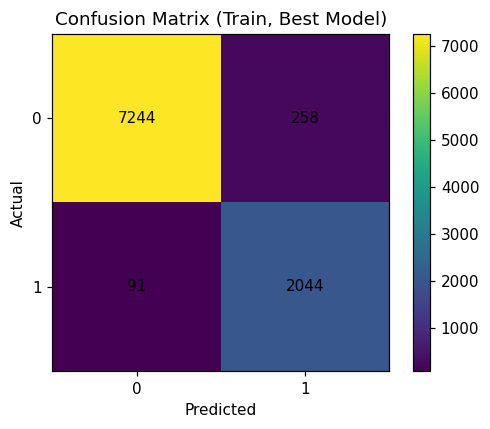

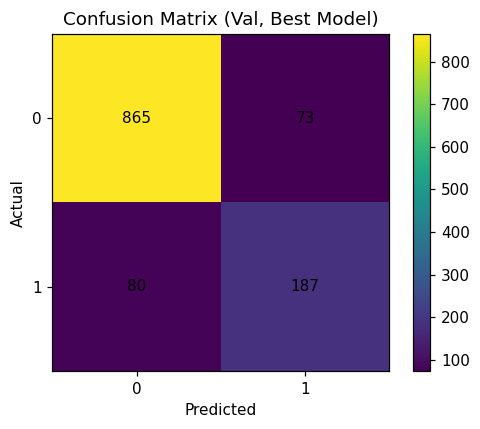

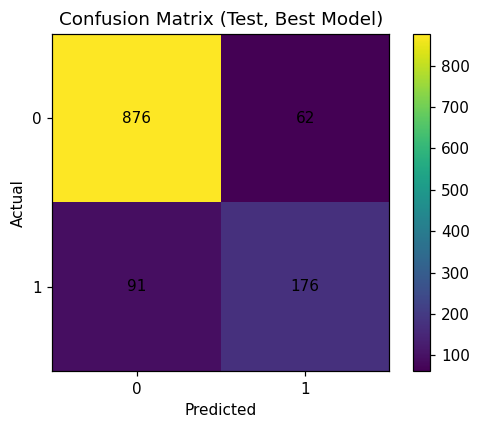

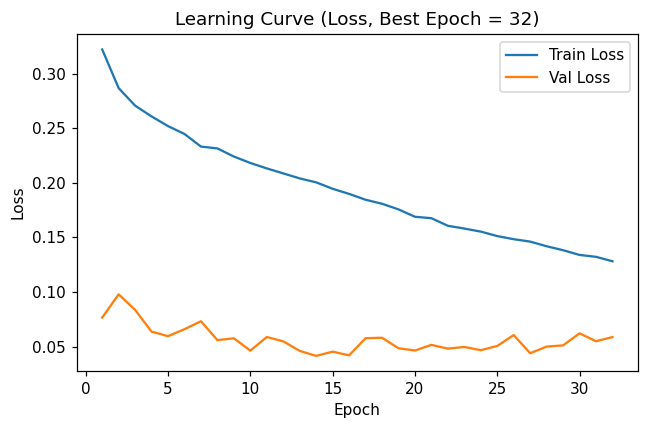

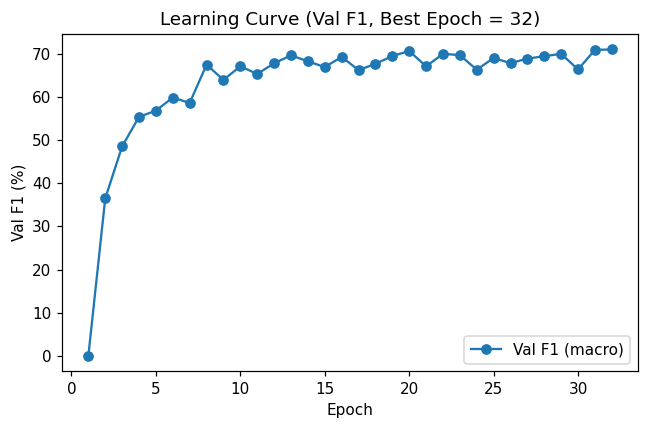

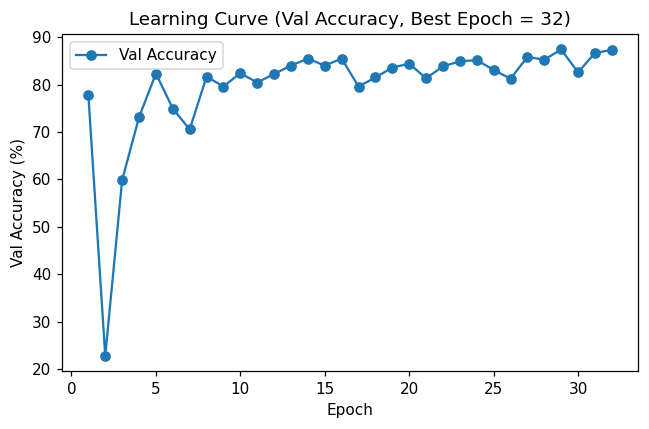

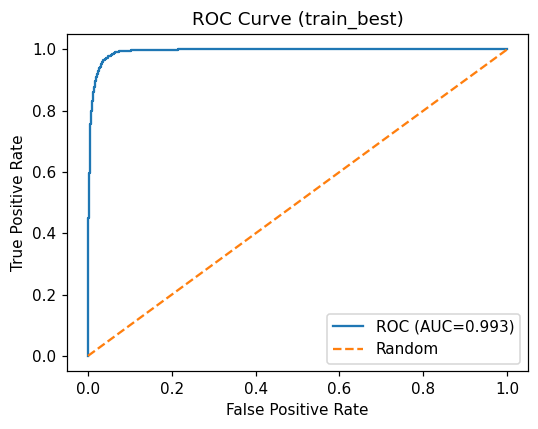

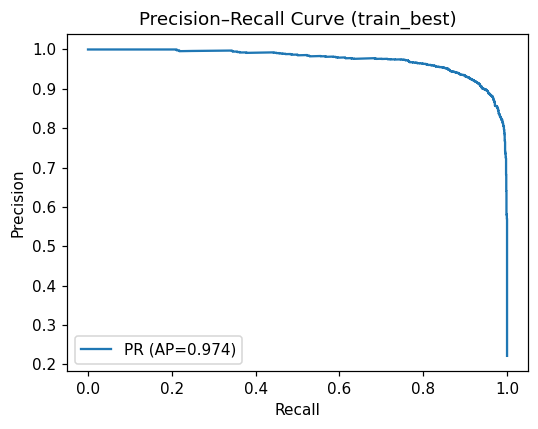

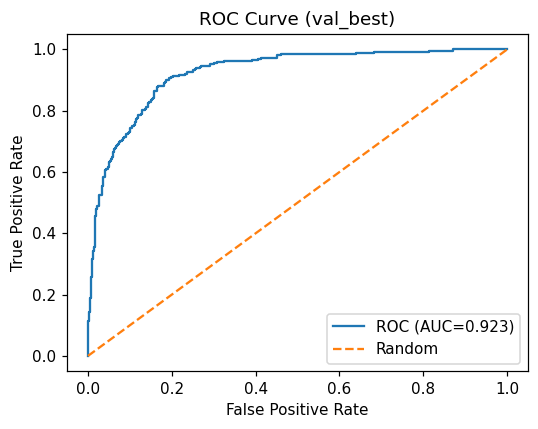

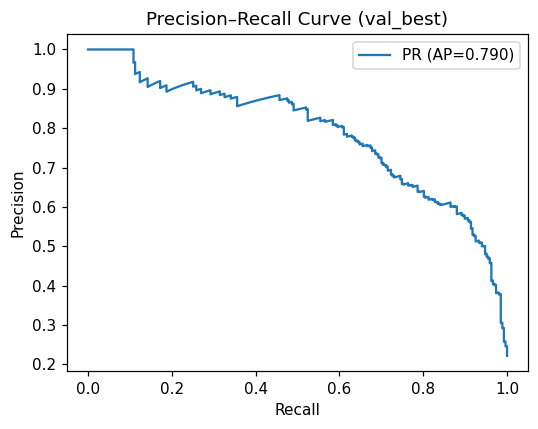

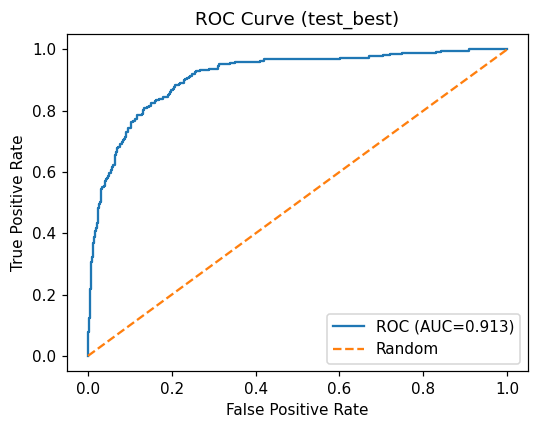

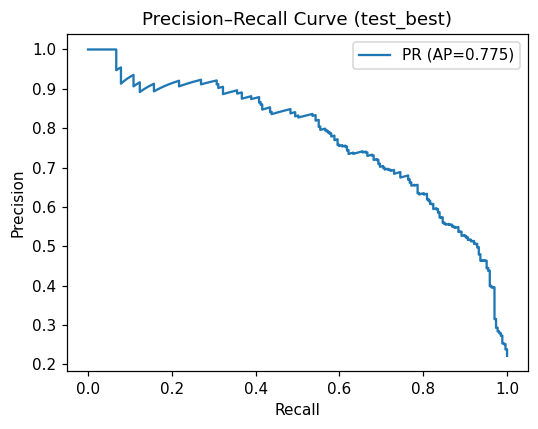

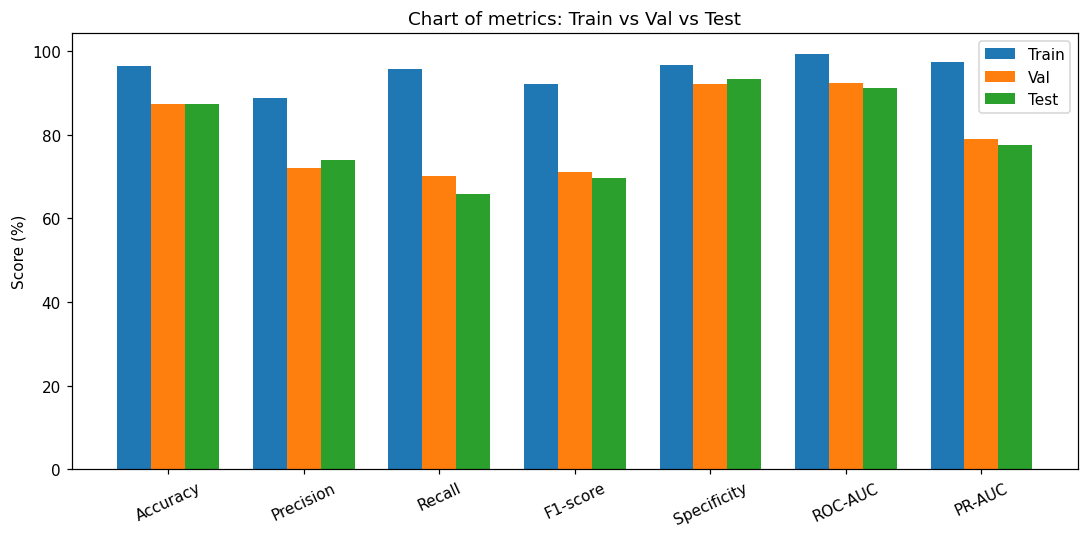

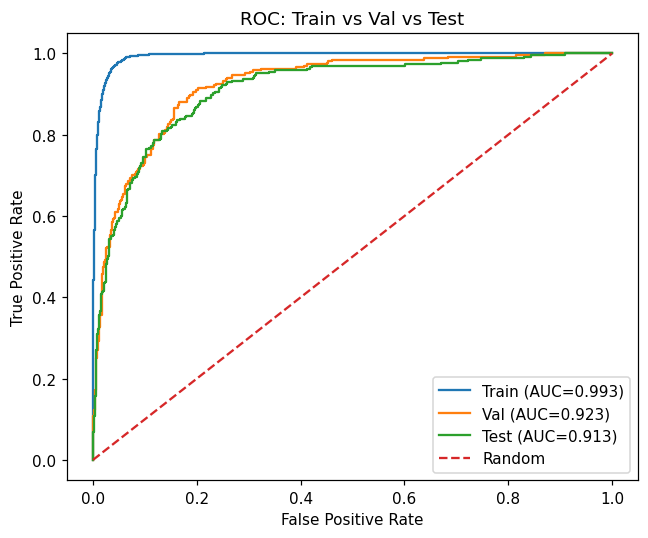

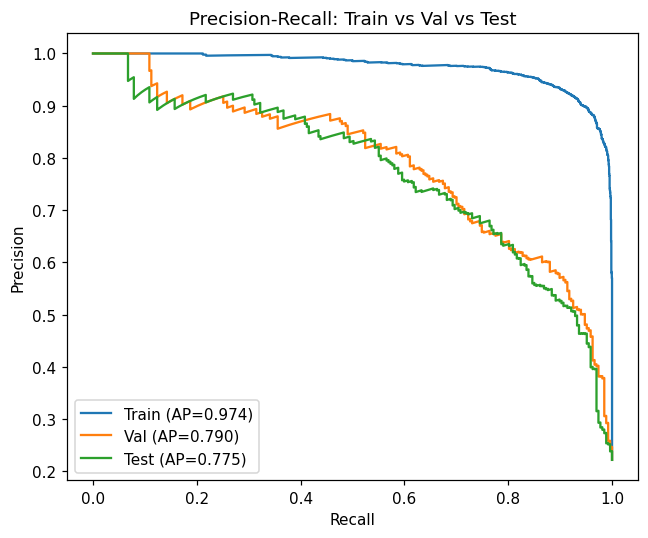

In [30]:
train_metrics_best, ytr_best, ptr_best, str_best = evaluate(model, dl_train_eval, device)
val_metrics_best,   yv_best,  pv_best,  sv_best  = evaluate(model, dl_val,        device)
test_metrics_best,  yt_best,  pt_best,  st_best  = evaluate(model, dl_test,       device)

train_pct = {k: round(v * 100, 3) for k, v in train_metrics_best.items()}
val_pct   = {k: round(v * 100, 3) for k, v in val_metrics_best.items()}
test_pct  = {k: round(v * 100, 3) for k, v in test_metrics_best.items()}

print("\n[Best model @ Train]")
print("Accuracy (%)        :", train_pct["acc"])
print("Precision (%)       :", train_pct["prec"])
print("Recall (%)          :", train_pct["rec"])
print("F1-Score (%)        :", train_pct["f1"])
print("Specificity (%)     :", train_pct["spec"])
print("ROC-AUC (%)         :", train_pct["roc_auc"])
print("Precision-recall (%):", train_pct["pr_auc"])

print("\n[Best model @ Val]")
print("Accuracy (%)        :", val_pct["acc"])
print("Precision (%)       :", val_pct["prec"])
print("Recall (%)          :", val_pct["rec"])
print("F1-Score (%)        :", val_pct["f1"])
print("Specificity (%)     :", val_pct["spec"])
print("ROC-AUC (%)         :", val_pct["roc_auc"])
print("Precision-recall (%):", val_pct["pr_auc"])

print("\n[Best model @ Test]")
print("Accuracy (%)        :", test_pct["acc"])
print("Precision (%)       :", test_pct["prec"])
print("Recall (%)          :", test_pct["rec"])
print("F1-Score (%)        :", test_pct["f1"])
print("Specificity (%)     :", test_pct["spec"])
print("ROC-AUC (%)         :", test_pct["roc_auc"])
print("Precision-recall (%):", test_pct["pr_auc"])

# confusion matrix
plot_confusion_matrix(
    ytr_best, ptr_best,
    out_path=os.path.join(OUT_DIR, "confmat_train_best.png"),
    title="Confusion Matrix (Train, Best Model)"
)

plot_confusion_matrix(
    yv_best, pv_best,
    out_path=os.path.join(OUT_DIR, "confmat_val_best.png"),
    title="Confusion Matrix (Val, Best Model)"
)

plot_confusion_matrix(
    yt_best, pt_best,
    out_path=os.path.join(OUT_DIR, "confmat_test_best.png"),
    title="Confusion Matrix (Test, Best Model)"
)

# learning curves
plot_learning_curves(
    history=history,
    best_epoch=best_epoch,
    out_dir=OUT_DIR,
    prefix="convnextv2_tiny_focal"
)

plot_accuracy_curve(
    history=history,
    best_epoch=best_epoch,
    out_dir=OUT_DIR,
    prefix="convnextv2_tiny_focal"
)

# roc/pr curves
plot_roc_pr(
    y_true=ytr_best,
    y_score=str_best,
    out_dir=OUT_DIR,
    prefix="train_best",
    roc_auc=train_metrics_best["roc_auc"],
    pr_auc=train_metrics_best["pr_auc"]
)

plot_roc_pr(
    y_true=yv_best,
    y_score=sv_best,
    out_dir=OUT_DIR,
    prefix="val_best",
    roc_auc=val_metrics_best["roc_auc"],
    pr_auc=val_metrics_best["pr_auc"]
)

plot_roc_pr(
    y_true=yt_best,
    y_score=st_best,
    out_dir=OUT_DIR,
    prefix="test_best",
    roc_auc=test_metrics_best["roc_auc"],
    pr_auc=test_metrics_best["pr_auc"]
)

plot_split_metrics_bar(
    train_metrics=train_metrics_best,
    val_metrics=val_metrics_best,
    test_metrics=test_metrics_best,
    out_dir=OUT_DIR,
    prefix="convnextv2_tiny_focal"
)

plot_roc_compare_splits(
    y_train=ytr_best, s_train=str_best,
    y_val=yv_best,    s_val=sv_best,
    y_test=yt_best,   s_test=st_best,
    out_dir=OUT_DIR,
    prefix="convnextv2_tiny_focal"
)

plot_pr_compare_splits(
    y_train=ytr_best, s_train=str_best,
    y_val=yv_best,    s_val=sv_best,
    y_test=yt_best,   s_test=st_best,
    out_dir=OUT_DIR,
    prefix="convnextv2_tiny_focal"
)


## Calibration

In [31]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

val_calib_df, val_thr_df = train_test_split(
    val_df,
    test_size=0.5,
    stratify=val_df["has_pneumo"],
    random_state=SEED + 2026
)

ds_calib = PandasImageDataset(val_calib_df, transform=eval_tfms)
ds_val_thr = PandasImageDataset(val_thr_df, transform=eval_tfms)

dl_calib = DataLoader(ds_calib, batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=True)
dl_val_thr = DataLoader(ds_val_thr, batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=True)

# 2) Collect logits
logits_calib, y_calib = collect_logits_labels(model, dl_calib, device)
logits_val_thr, y_val_thr = collect_logits_labels(model, dl_val_thr, device)
logits_test, y_test = collect_logits_labels(model, dl_test, device)

# 3) Fit temperature
T = fit_temperature_binary(logits_calib, y_calib, device=device, max_iter=50)
print(f"[Calibration] Fitted temperature T = {T:.4f}")

p_val_uncal = sigmoid_np(logits_val_thr)
p_val_cal   = sigmoid_np(logits_val_thr / T)

p_test_uncal = sigmoid_np(logits_test)
p_test_cal   = sigmoid_np(logits_test / T)

print("\n[Val_thr calibration metrics]")
print("  ECE  (uncal):", ece_binary(y_val_thr, p_val_uncal))
print("  ECE  (cal)  :", ece_binary(y_val_thr, p_val_cal))
print("  Brier(uncal):", brier_score(y_val_thr, p_val_uncal))
print("  Brier(cal)  :", brier_score(y_val_thr, p_val_cal))

print("\n[Test calibration metrics]")
print("  ECE  (uncal):", ece_binary(y_test, p_test_uncal))
print("  ECE  (cal)  :", ece_binary(y_test, p_test_cal))
print("  Brier(uncal):", brier_score(y_test, p_test_uncal))
print("  Brier(cal)  :", brier_score(y_test, p_test_cal))

c:\Users\Steven\anaconda3\envs\pytorch-gpu\lib\site-packages\torch\optim\lbfgs.py:457: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:836.)
  loss = float(closure())


[Calibration] Fitted temperature T = 0.9699

[Val_thr calibration metrics]
  ECE  (uncal): 0.030364225296682423
  ECE  (cal)  : 0.027413761850902146
  Brier(uncal): 0.0859535248788608
  Brier(cal)  : 0.08589724998353244

[Test calibration metrics]
  ECE  (uncal): 0.023702193577189324
  ECE  (cal)  : 0.023496340466453842
  Brier(uncal): 0.09118388319780468
  Brier(cal)  : 0.09123008349996146


In [32]:
import os
import numpy as np
import matplotlib.pyplot as plt

def _bin_stats_prob(y_true, p, n_bins=15):
    """
    Bin by predicted probability p in [0,1].
    Returns:
      bin_centers, mean_p, frac_pos, counts, ece_contrib, brier_bin
    """
    y = np.asarray(y_true).astype(np.float64).ravel()
    p = np.asarray(p).astype(np.float64).ravel()
    p = np.clip(p, 0.0, 1.0)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(p, bins) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)

    mean_p = np.full(n_bins, np.nan, dtype=np.float64)
    frac_pos = np.full(n_bins, np.nan, dtype=np.float64)
    brier_bin = np.full(n_bins, np.nan, dtype=np.float64)
    counts = np.zeros(n_bins, dtype=np.int64)

    for b in range(n_bins):
        m = (bin_ids == b)
        c = int(m.sum())
        counts[b] = c
        if c == 0:
            continue
        pb = p[m]
        yb = y[m]
        mean_p[b] = pb.mean()
        frac_pos[b] = yb.mean()
        brier_bin[b] = np.mean((pb - yb) ** 2)

    N = max(1, len(y))
    ece_contrib = np.nan_to_num(np.abs(frac_pos - mean_p), nan=0.0) * (counts / N)

    bin_centers = (bins[:-1] + bins[1:]) / 2.0
    return bin_centers, mean_p, frac_pos, counts, ece_contrib, brier_bin

def ece_prob_binned(y_true, p, n_bins=15):
    _, _, _, _, ece_contrib, _ = _bin_stats_prob(y_true, p, n_bins=n_bins)
    return float(np.sum(ece_contrib))

def brier_score(y_true, p):
    y = np.asarray(y_true).astype(np.float64).ravel()
    p = np.asarray(p).astype(np.float64).ravel()
    p = np.clip(p, 0.0, 1.0)
    return float(np.mean((p - y) ** 2))


In [33]:
def plot_reliability_barline(y_true, p, title, out_path=None, n_bins=10, show_metrics=True):
    import os
    import numpy as np
    import matplotlib.pyplot as plt

    y = np.asarray(y_true).astype(np.float64).ravel()
    p = np.asarray(p).astype(np.float64).ravel()
    p = np.clip(p, 0.0, 1.0)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(p, bins) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)

    mean_conf = np.full(n_bins, np.nan, dtype=np.float64)
    frac_pos  = np.full(n_bins, np.nan, dtype=np.float64)
    counts    = np.zeros(n_bins, dtype=np.int64)

    for b in range(n_bins):
        m = (bin_ids == b)
        c = int(m.sum())
        counts[b] = c
        if c == 0:
            continue
        mean_conf[b] = p[m].mean()
        frac_pos[b]  = y[m].mean()

    # --- ECE & Brier ---
    N = max(1, len(y))
    ece = 0.0
    for b in range(n_bins):
        if counts[b] == 0:
            continue
        ece += abs(frac_pos[b] - mean_conf[b]) * (counts[b] / N)

    brier = float(np.mean((p - y) ** 2))

    centers = (bins[:-1] + bins[1:]) / 2.0
    width = (bins[1] - bins[0]) * 0.9

    plt.figure()

    # 线1：Perfect（强制虚线）
    plt.plot(
        [0, 1], [0, 1],
        linestyle="--",
        linewidth=1.5,
        label="Perfect",
        zorder=3
    )

    m = counts > 0

    # bar：Empirical（放在底层）
    plt.bar(
        centers[m], frac_pos[m],
        width=width,
        alpha=0.6,
        label="Empirical",
        zorder=1
    )

    # 线2：Mean conf（强制实线 + 橙色 + 置顶）
    plt.plot(
        centers[m], mean_conf[m],
        linestyle="-",
        linewidth=2.0,
        marker="o",
        markersize=4,
        color="tab:orange",
        label="Mean conf",
        zorder=4
    )

    plt.xlabel("Predicted probability")
    plt.ylabel("Fraction of positives")

    if show_metrics:
        plt.title(f"{title}\n(ECE={ece:.3f}, Brier={brier:.3f})")
    else:
        plt.title(title)

    plt.legend(loc="upper left")

    if out_path:
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        plt.savefig(out_path, dpi=200, bbox_inches="tight")

    plt.show()

    return {"ece": float(ece), "brier": float(brier)}


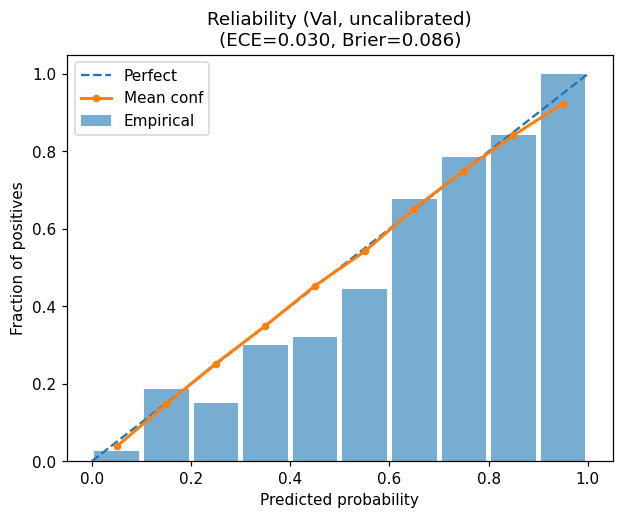

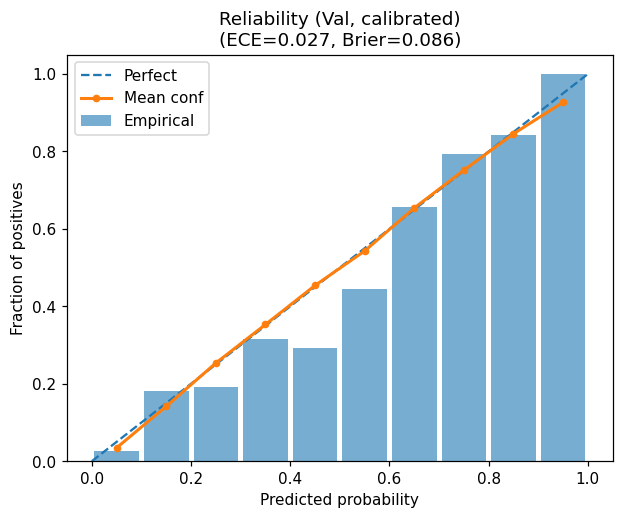

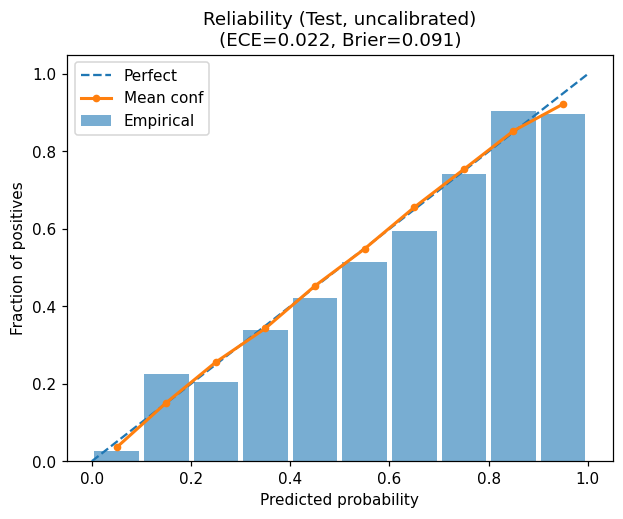

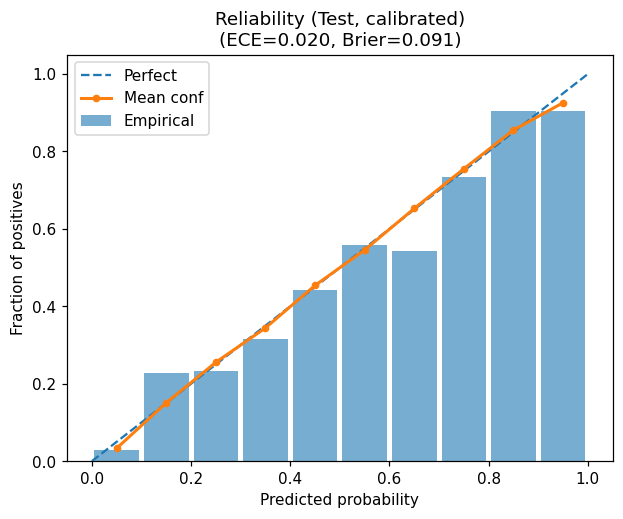

{'ece': 0.020497893150634525, 'brier': 0.09123008349996146}

In [34]:
import os

NBINS = 10

# ---- Val_thr: uncalibrated vs calibrated ----
plot_reliability_barline(
    y_val_thr, p_val_uncal,
    title="Reliability (Val, uncalibrated)",
    out_path=os.path.join(OUT_DIR, "val_uncal_reliability.png"),
    n_bins=NBINS,
    show_metrics=True
)

plot_reliability_barline(
    y_val_thr, p_val_cal,
    title="Reliability (Val, calibrated)",
    out_path=os.path.join(OUT_DIR, "val_cal_reliability.png"),
    n_bins=NBINS,
    show_metrics=True
)

# ---- Test: uncalibrated vs calibrated ----
plot_reliability_barline(
    y_test, p_test_uncal,
    title="Reliability (Test, uncalibrated)",
    out_path=os.path.join(OUT_DIR, "test_uncal_reliability.png"),
    n_bins=NBINS,
    show_metrics=True
)

plot_reliability_barline(
    y_test, p_test_cal,
    title="Reliability (Test, calibrated)",
    out_path=os.path.join(OUT_DIR, "test_cal_reliability.png"),
    n_bins=NBINS,
    show_metrics=True
)


## Display mask on images

In [35]:
def compute_dice_iou(preds: torch.Tensor, targets: torch.Tensor, eps: float = 1e-6):
    preds_f   = preds.view(preds.size(0), -1)
    targets_f = targets.view(targets.size(0), -1)

    inter = (preds_f * targets_f).sum(dim=1)
    union = preds_f.sum(dim=1) + targets_f.sum(dim=1)

    dice = (2.0 * inter + eps) / (union + eps)

    iou_den = (preds_f + targets_f - preds_f * targets_f).sum(dim=1)
    iou = (inter + eps) / (iou_den + eps)

    return dice, iou


def denormalize(img_tensor: torch.Tensor):
    img = img_tensor.detach().cpu().clone()
    img = img * 0.25 + 0.5   # x * std + mean
    img = img.clamp(0.0, 1.0)
    return img.squeeze(0).numpy()

@torch.no_grad()
def visualize_segmentation_examples(
    model,
    loader,
    device,
    threshold: float = 0.5,
    num_pos: int = 2,
    num_neg: int = 2,
    num_hard: int = 2,
    save_dir: str = None,
    prefix: str = "seg_example",
):

    model.eval()
    pos_shown = neg_shown = hard_shown = 0
    example_idx = 0 

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    for xb, yb, mb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        mb = mb.to(device, non_blocking=True)

        out = model(xb)
        if isinstance(out, tuple):
            _, seg_logits = out  # (cls_logits, seg_logits)
        else:
            raise ValueError("Model output must be (cls_logits, seg_logits)")

        # [B,1,H,W]
        probs = torch.sigmoid(seg_logits)
        preds = (probs >= threshold).float()

        dice_batch, iou_batch = compute_dice_iou(preds, mb)

        for i in range(xb.size(0)):
            dice_val = float(dice_batch[i].cpu().item())
            iou_val  = float(iou_batch[i].cpu().item())
            label    = int(yb[i].cpu().item())

            category = None
            title_suffix = ""

            if label == 1 and dice_val >= 0.8 and pos_shown < num_pos:
                category = "pos"
                title_suffix = f"Positive, easy (Dice={dice_val:.2f}, IoU={iou_val:.2f})"

            elif label == 0 and dice_val >= 0.95 and neg_shown < num_neg:
                category = "neg"
                title_suffix = f"Negative (Dice={dice_val:.2f}, IoU={iou_val:.2f})"

            elif label == 1 and 0.3 <= dice_val <= 0.7 and hard_shown < num_hard:
                category = "hard"
                title_suffix = f"Positive, hard (Dice={dice_val:.2f}, IoU={iou_val:.2f})"

            if category is None:
                continue

            img_np  = denormalize(xb[i])                # [H,W]
            gt_mask = mb[i].detach().cpu().numpy().squeeze()   # [H,W]
            pr_mask = preds[i].detach().cpu().numpy().squeeze() # [H,W]

            fig, axes = plt.subplots(1, 3, figsize=(12, 4))

            axes[0].imshow(img_np, cmap="gray")
            axes[0].set_title(f"Image (label={label})")
            axes[0].axis("off")

            axes[1].imshow(img_np, cmap="gray")
            axes[1].imshow(gt_mask, cmap="jet", alpha=0.4)
            axes[1].set_title("Ground Truth mask (overlay)")
            axes[1].axis("off")

            axes[2].imshow(img_np, cmap="gray")
            axes[2].imshow(pr_mask, cmap="jet", alpha=0.4)
            axes[2].set_title(f"Predicted mask\nDice={dice_val:.2f}, IoU={iou_val:.2f}")
            axes[2].axis("off")

            plt.suptitle(title_suffix)
            plt.tight_layout()

            if save_dir is not None:
                fname = f"{prefix}_{category}_{example_idx}.png"
                fig.savefig(os.path.join(save_dir, fname), dpi=300)

            plt.show()
            example_idx += 1

            if category == "pos":
                pos_shown += 1
            elif category == "neg":
                neg_shown += 1
            elif category == "hard":
                hard_shown += 1

            if pos_shown >= num_pos and neg_shown >= num_neg and hard_shown >= num_hard:
                return

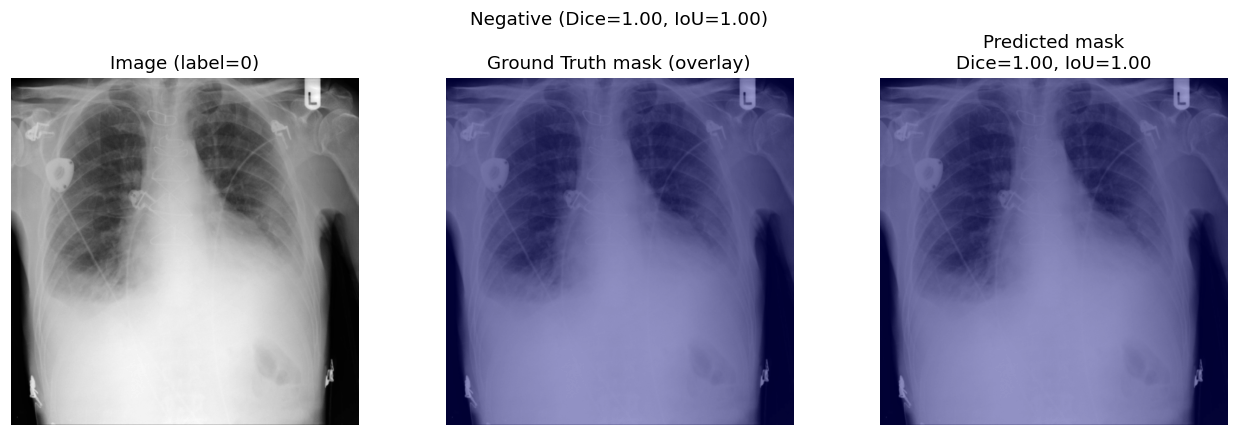

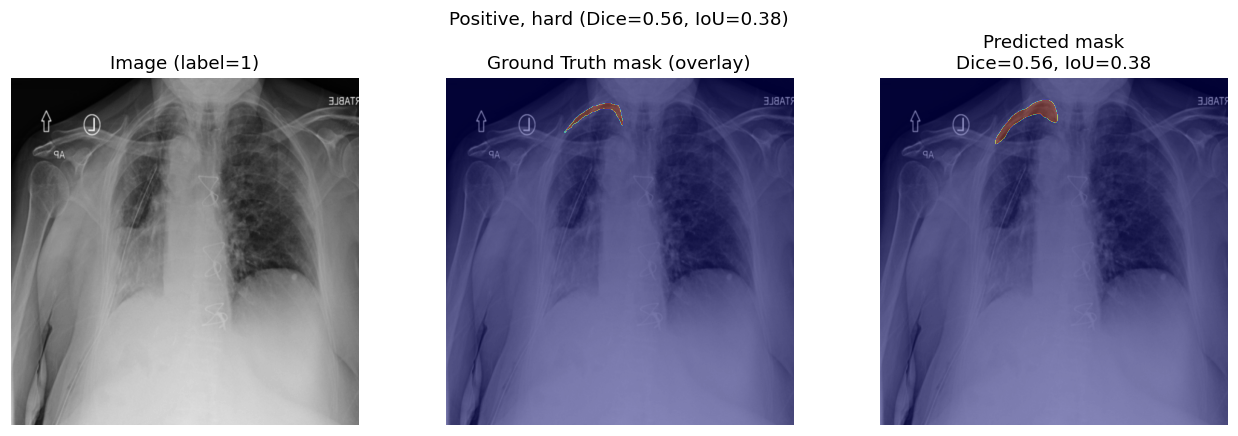

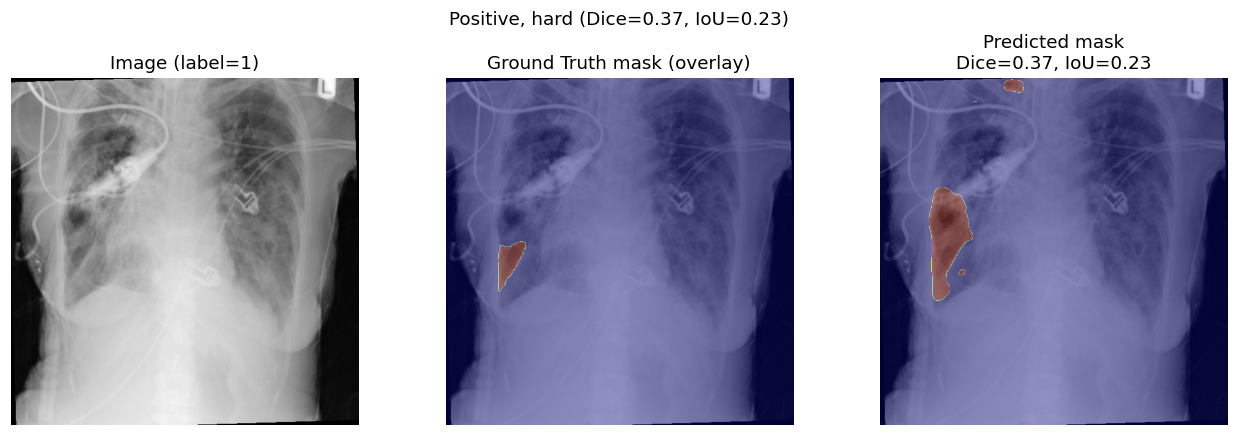

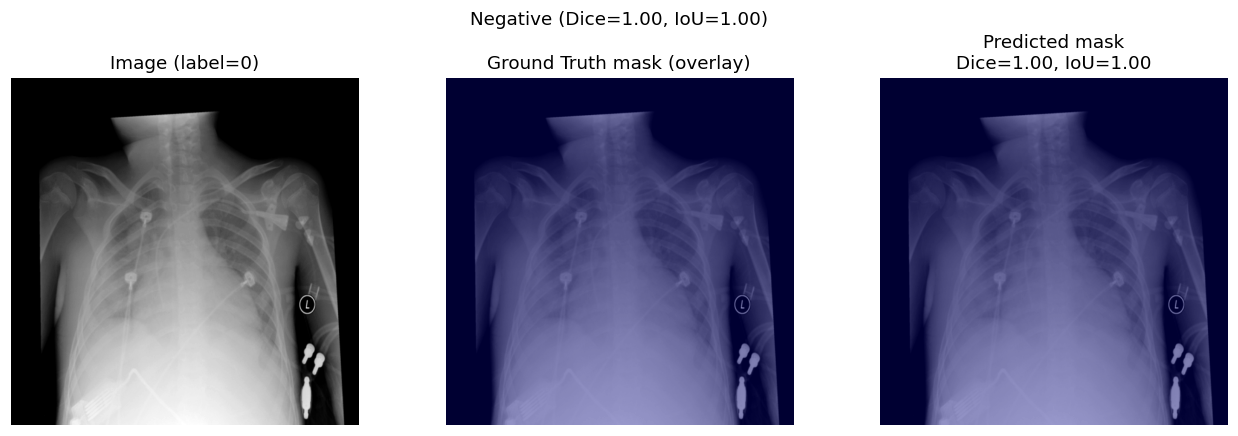

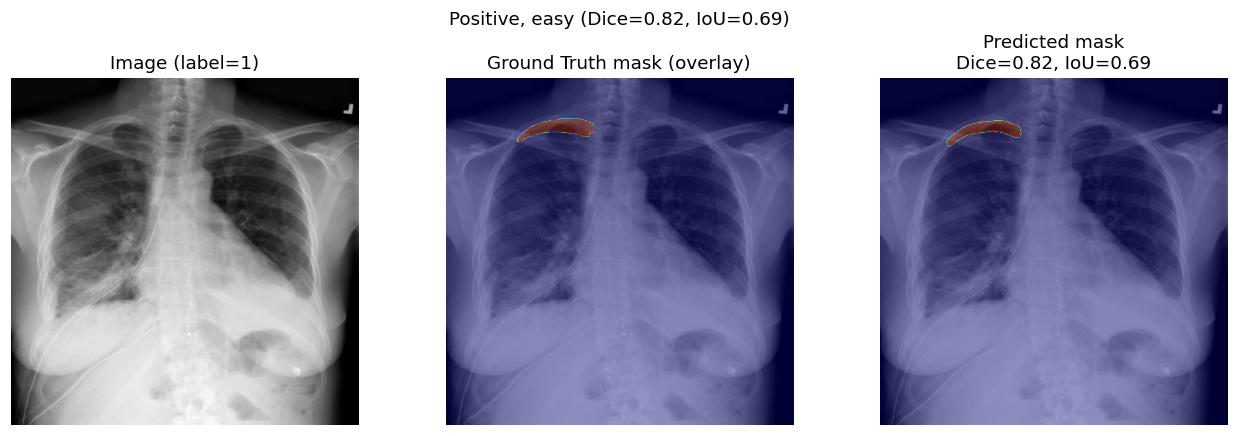

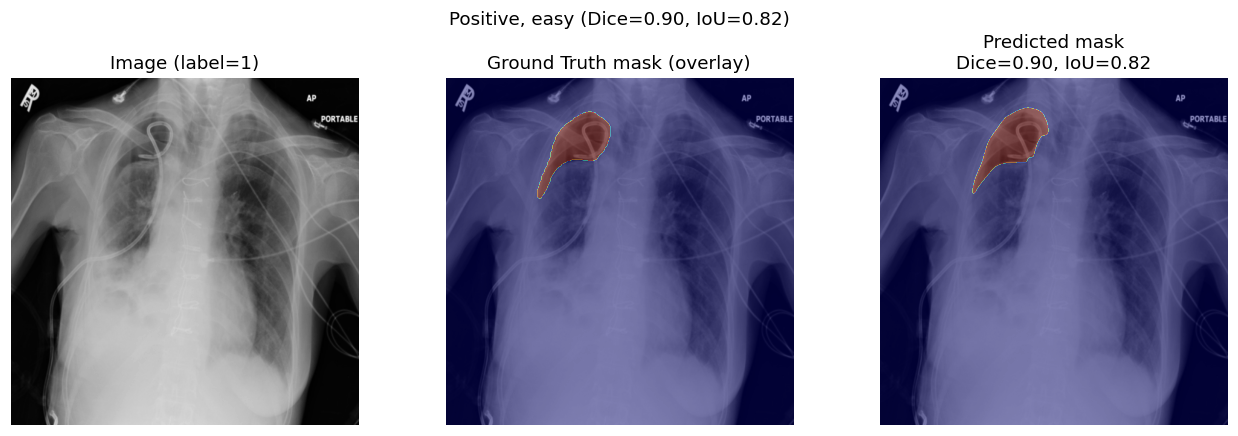

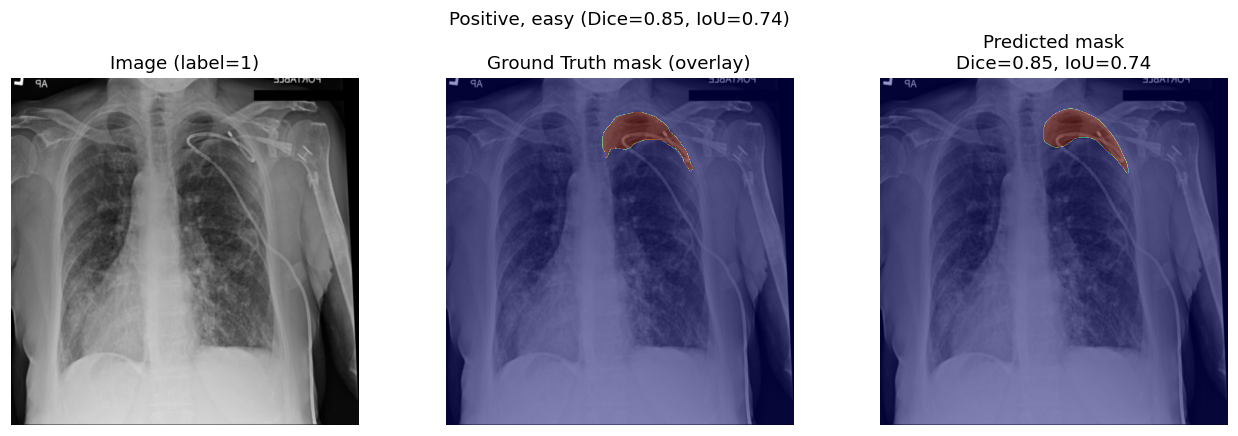

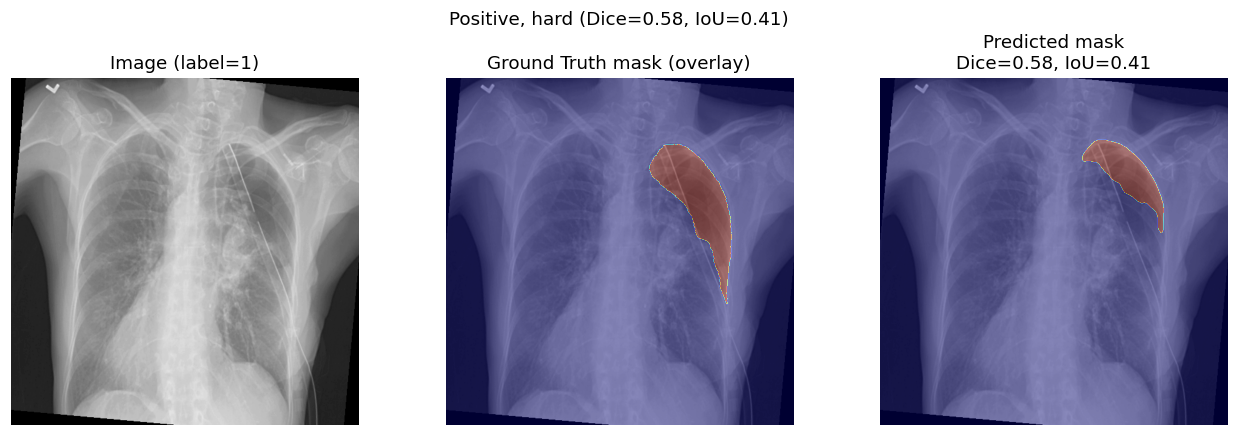

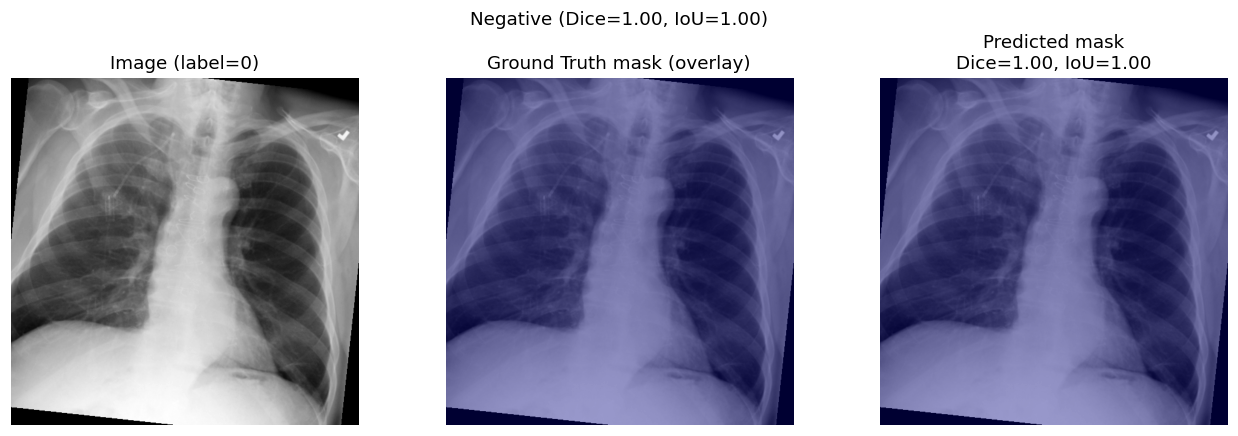

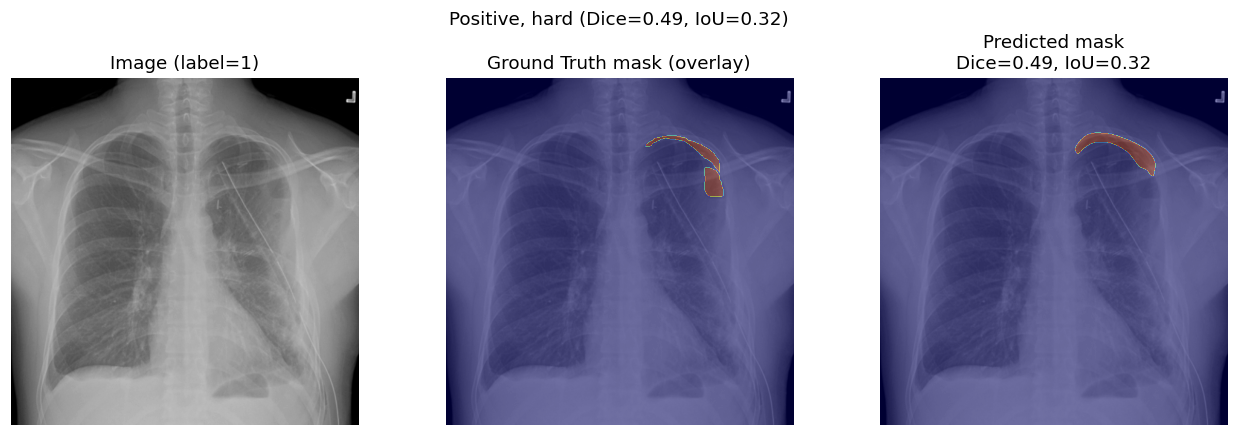

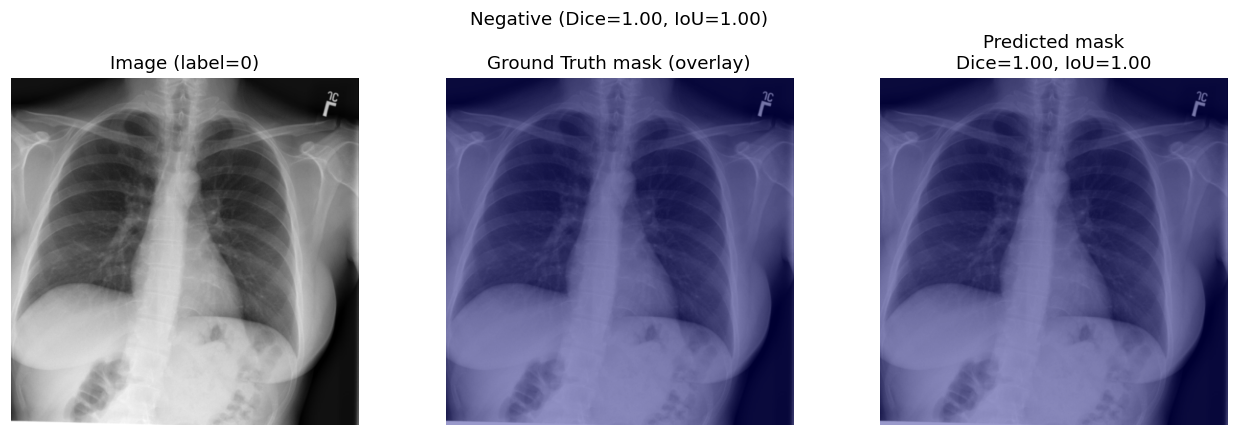

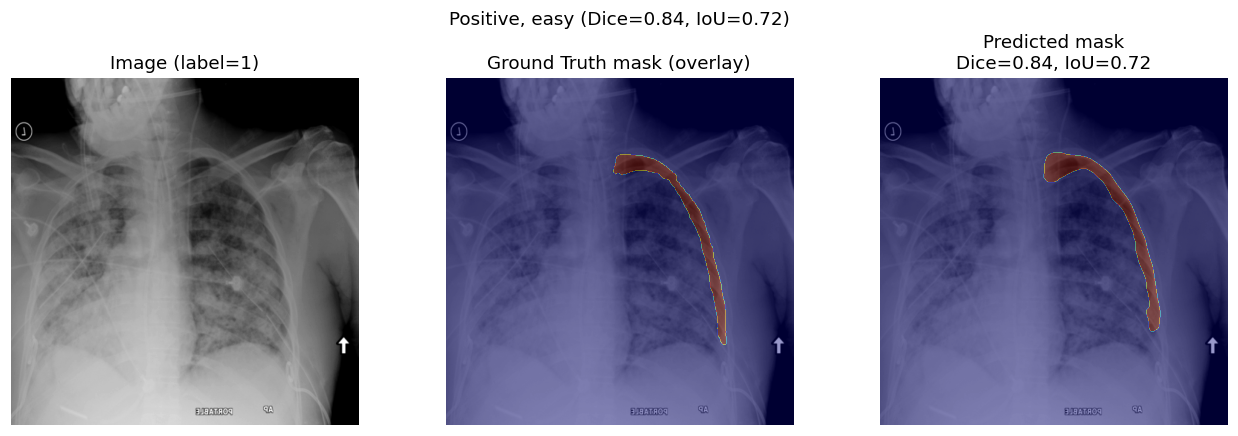

In [36]:
visualize_segmentation_examples(
    model=model,        
    loader=dl_train,    
    device=device,
    threshold=0.5,   
    num_pos=2,
    num_neg=2,
    num_hard=2,
    save_dir=OUT_DIR, 
    prefix="seg_train_examples"
)

eval_mask_tfms = JointImageMaskTransform(out_size=IMG_SIZE)

ds_test_seg = PandasImageMaskDataset(test_df, mask_root=MASK_ROOT, joint_transform=eval_mask_tfms)
dl_test_seg = DataLoader(ds_test_seg, batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=True)

visualize_segmentation_examples(
    model=model,
    loader=dl_test_seg,
    device=device,
    threshold=0.5,
    num_pos=2,
    num_neg=2,
    num_hard=2,
    save_dir=OUT_DIR,
    prefix="seg_test_examples"
)



=== Top 10 thresholds on val (sorted by f1) ===
threshold    acc   prec    rec     f1   spec
    0.510 88.391 73.881 73.881 73.881 92.537
    0.530 88.723 76.190 71.642 73.846 93.603
    0.480 87.894 71.329 76.119 73.646 91.258
    0.540 88.723 76.613 70.896 73.643 93.817
    0.500 88.060 72.464 74.627 73.529 91.898
    0.550 88.723 77.049 70.149 73.438 94.030
    0.490 87.894 71.942 74.627 73.260 91.684
    0.520 88.226 74.046 72.388 73.208 92.751
    0.440 87.065 67.949 79.104 73.103 89.339
    0.470 87.396 69.595 76.866 73.050 90.405

Best threshold on validation set (by f1):
t = 0.510, Acc=88.391%, Prec=73.881%, Rec=73.881%, F1=73.881%, Spec=92.537%


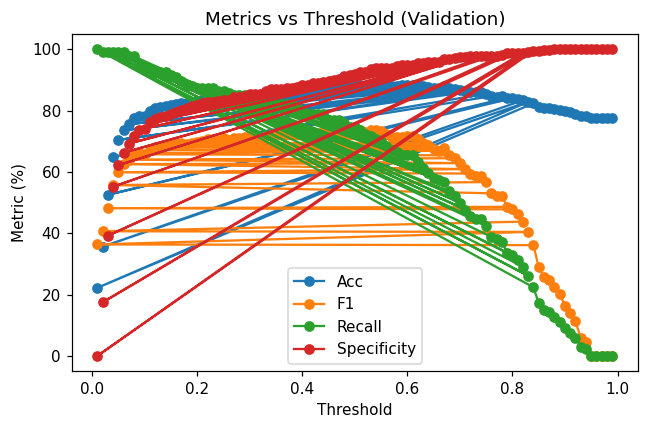


>>> Best threshold on val_thr after temperature scaling: best_t = 0.510

[Temp+Threshold model @ Test (T=0.970, t=0.510)]
Accuracy (%)        : 86.97095435684648
Precision (%)       : 73.70689655172413
Recall (%)          : 64.04494382022472
F1-Score (%)        : 68.5370741482966
Specificity (%)     : 93.49680170476016
ROC-AUC (%)         : 91.25799573560766
Precision-recall (%): 77.5067672855886

[Best threshold model @ Val (t=0.510)]
Accuracy (%)        : 87.635
Precision (%)       : 73.413
Recall (%)          : 69.288
F1-Score (%)        : 71.291


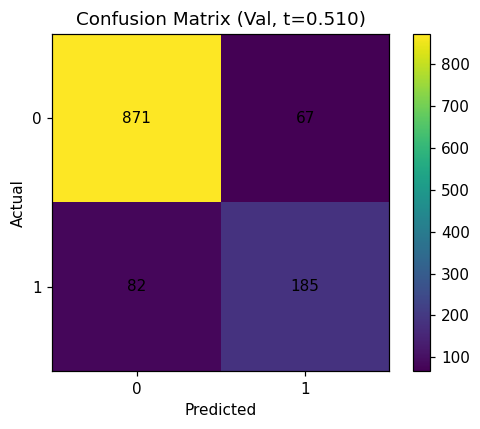

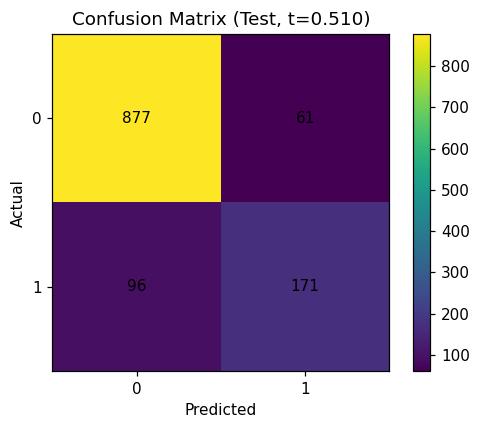

In [38]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, average_precision_score
)

def sweep_thresholds(y_true, y_score, thresholds=None, sort_by="f1", verbose=True):
    y_true = np.asarray(y_true).astype(int).ravel()
    y_score = np.asarray(y_score).ravel()

    if thresholds is None:
        thresholds = np.linspace(0.01, 0.95, 19)

    results = []
    for t in thresholds:
        y_pred = (y_score >= t).astype(int)

        acc  = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec  = recall_score(y_true, y_pred, zero_division=0)
        f1   = f1_score(y_true, y_pred, zero_division=0)

        cm = confusion_matrix(y_true, y_pred)
        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
            spec = tn / (tn + fp + 1e-8)
        else:
            spec = float("nan")

        results.append({
            "threshold": t,
            "acc": acc,
            "prec": prec,
            "rec": rec,
            "f1": f1,
            "spec": spec,
        })

    df_thr = pd.DataFrame(results)
    df_thr_sorted = df_thr.sort_values(sort_by, ascending=False).reset_index(drop=True)

    if verbose:
        print(f"\n=== Top 10 thresholds on val (sorted by {sort_by}) ===")
        tmp = df_thr_sorted.copy()
        for col in ["acc", "prec", "rec", "f1", "spec"]:
            tmp[col] = tmp[col] * 100.0
        print(tmp.head(10).to_string(index=False, 
                                     formatters={"threshold": "{:.3f}".format,
                                                 "acc": "{:.3f}".format,
                                                 "prec": "{:.3f}".format,
                                                 "rec": "{:.3f}".format,
                                                 "f1": "{:.3f}".format,
                                                 "spec": "{:.3f}".format}))

        best_row = df_thr_sorted.iloc[0]
        print("\nBest threshold on validation set (by {}):".format(sort_by))
        print(
            f"t = {best_row['threshold']:.3f}, "
            f"Acc={best_row['acc']*100:.3f}%, "
            f"Prec={best_row['prec']*100:.3f}%, "
            f"Rec={best_row['rec']*100:.3f}%, "
            f"F1={best_row['f1']*100:.3f}%, "
            f"Spec={best_row['spec']*100:.3f}%"
        )

    return df_thr_sorted

def plot_threshold_metrics(df_thr, out_dir, prefix="val_thr"):
    os.makedirs(out_dir, exist_ok=True)

    thr = df_thr["threshold"].values

    plt.figure(figsize=(6,4))
    for key, label in [
        ("acc",  "Acc"),
        ("f1",   "F1"),
        ("rec",  "Recall"),
        ("spec", "Specificity"),
    ]:
        if key in df_thr.columns:
            plt.plot(thr, df_thr[key].values * 100.0, marker="o", label=label)

    plt.xlabel("Threshold")
    plt.ylabel("Metric (%)")
    plt.title("Metrics vs Threshold (Validation)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{prefix}_metrics_vs_threshold.png"), dpi=300)
    plt.show()

df_thr_val = sweep_thresholds(
    y_val_thr,
    p_val_cal,
    thresholds=np.linspace(0.01, 0.99, 99),
    sort_by="f1",
    verbose=True
)
plot_threshold_metrics(df_thr_val, OUT_DIR, prefix="val_thr_calibrated")

best_t = float(df_thr_val.iloc[0]["threshold"])
print(f"\n>>> Best threshold on val_thr after temperature scaling: best_t = {best_t:.3f}")

y_test_pred = (p_test_cal >= best_t).astype(int)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, average_precision_score

test_acc  = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred, zero_division=0)
test_rec  = recall_score(y_test, y_test_pred, zero_division=0)
test_f1   = f1_score(y_test, y_test_pred, zero_division=0)

cm_test = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm_test.ravel()
test_spec = tn / (tn + fp + 1e-8)

test_roc = roc_auc_score(y_test, p_test_cal)
test_pr  = average_precision_score(y_test, p_test_cal)

print(f"\n[Temp+Threshold model @ Test (T={T:.3f}, t={best_t:.3f})]")
print("Accuracy (%)        :", test_acc*100)
print("Precision (%)       :", test_prec*100)
print("Recall (%)          :", test_rec*100)
print("F1-Score (%)        :", test_f1*100)
print("Specificity (%)     :", test_spec*100)
print("ROC-AUC (%)         :", test_roc*100)
print("Precision-recall (%):", test_pr*100)


y_val_pred = (np.asarray(sv_best) >= best_t).astype(int)
val_acc2  = accuracy_score(yv_best, y_val_pred)
val_prec2 = precision_score(yv_best, y_val_pred, zero_division=0)
val_rec2  = recall_score(yv_best, y_val_pred, zero_division=0)
val_f12   = f1_score(yv_best, y_val_pred, zero_division=0)

print(f"\n[Best threshold model @ Val (t={best_t:.3f})]")
print(f"Accuracy (%)        : {val_acc2*100:.3f}")
print(f"Precision (%)       : {val_prec2*100:.3f}")
print(f"Recall (%)          : {val_rec2*100:.3f}")
print(f"F1-Score (%)        : {val_f12*100:.3f}")

# --- Confusion matrix at best threshold ---

# Val
plot_confusion_matrix(
    y_true=yv_best,
    y_pred=y_val_pred,
    out_path=os.path.join(OUT_DIR, f"confmat_val_best_t_{best_t:.3f}.png"),
    title=f"Confusion Matrix (Val, t={best_t:.3f})"
)

# Test
plot_confusion_matrix(
    y_true=y_test,
    y_pred=y_test_pred,
    out_path=os.path.join(OUT_DIR, f"confmat_test_best_t_{best_t:.3f}.png"),
    title=f"Confusion Matrix (Test, t={best_t:.3f})"
)

In [ ]:
import pandas as pd

rows = [
    {
        "Split": "Train (Best)",
        "Accuracy (%)":         train_pct["acc"],
        "Precision (%)":        train_pct["prec"],
        "Recall (%)":           train_pct["rec"],
        "F1-Score (%)":         train_pct["f1"],
        "Specificity (%)":      train_pct["spec"],
        "ROC-AUC (%)":          train_pct["roc_auc"],
        "Precision-recall (%)": train_pct["pr_auc"],
    },
    {
        "Split": "Val (Best)",
        "Accuracy (%)":         val_pct["acc"],
        "Precision (%)":        val_pct["prec"],
        "Recall (%)":           val_pct["rec"],
        "F1-Score (%)":         val_pct["f1"],
        "Specificity (%)":      val_pct["spec"],
        "ROC-AUC (%)":          val_pct["roc_auc"],
        "Precision-recall (%)": val_pct["pr_auc"],
    },
    {
        "Split": "Test (Best)",
        "Accuracy (%)":         test_pct["acc"],
        "Precision (%)":        test_pct["prec"],
        "Recall (%)":           test_pct["rec"],
        "F1-Score (%)":         test_pct["f1"],
        "Specificity (%)":      test_pct["spec"],
        "ROC-AUC (%)":          test_pct["roc_auc"],
        "Precision-recall (%)": test_pct["pr_auc"],
    },
]

df_best = pd.DataFrame(rows)
print(df_best)

df_best.to_csv(os.path.join(OUT_DIR, "best_train_val_test_metrics_convnextv2.csv"), index=False, mode="w")


          Split  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)  \
0  Train (Best)        95.258         84.584      96.112        89.980   
1    Val (Best)        87.967         71.181      76.779        73.874   
2   Test (Best)        87.718         70.877      75.655        73.188   

   Specificity (%)  ROC-AUC (%)  Precision-recall (%)  
0           95.015       99.011                96.177  
1           91.151       92.713                80.470  
2           91.151       92.781                81.412  
